# Revenue Index — Scenario Matrix

Stage 4, step 2. Computes the annual revenue index across all nine
penetration x temperature combinations and produces the risk metrics the thesis
quotes.

## Objective
Apply the production chain to the reconstructed Monte Carlo paths under three
solar-penetration and three temperature scenarios, aggregate to annual, and
report the distribution, risk metrics and value loss of each combination against
the reference case.

The two scenario axes enter at different points, which is why this notebook
exists separately from the reconstruction:

- **Penetration** changes the capture rate, so it is baked into the three
  reconstructed files and arrives as three different `CR_sim` arrays.
- **Temperature** is an additive daily delta on `T_sim`, so it can be applied
  here. That is why `P(t)` is computed three times, not nine: it depends on the
  temperature scenario only, and is reused across penetration scenarios.

All nine combinations share one draw of the underlying innovations, so a
difference between two cells is the assumption and not Monte Carlo noise.

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Data/Simulated/mc_physical_variables_{current_trend,pniec,entso_e}.parquet` | Production chain per temperature scenario -> RI per combination -> annual aggregation -> risk metrics | `Data/Results/ri_annual_results_multiscenario.parquet` |
| `Data/Cleaned/df_temperature_scenarios.parquet` (SSP deltas) | | `Data/Results/risk_metrics_summary.parquet` |
| `Code/Models/Temperature/noct_uplift_params.pkl` | | |
| `Data/Results/ri_annual_results_hist.parquet` (historical anchor) | | |

## Decision Log

| # | Decision | Alternatives | Rationale | Impact |
|---|---|---|---|---|
| D1 | Reference scenario is (PNIEC 2024, Baseline temperature) | The mid-point of each axis chosen independently | PNIEC is Italy's own published trajectory, and the baseline temperature path is the fitted historical trend rather than an SSP assumption, so the reference rests on the fewest added assumptions | Every `delta_vs_ref` column and the waterfall decomposition are measured from this cell |
| D2 | `P(t)` computed once per temperature scenario and reused across penetration scenarios | Compute all nine independently | Irradiance and temperature paths are shared across penetration files by construction, so nine computations would produce three distinct answers repeated three times each | Three times less compute and memory, and it makes the shared-path property explicit rather than incidental |
| D3 | Path count and date grid asserted identical across all three scenario files **before** reshaping | Trust that the reconstruction wrote them consistently | A scenario file written at a different path count than its neighbours reshapes without complaint and lands in the results artifact at a different Monte Carlo precision, with no error raised | Cross-scenario comparisons are only meaningful when every cell is estimated from the same number of paths |
| D4 | Written row count asserted to be exactly `9 x N_SIM x n_years` | Report the row count and move on | The same reasoning as D3, applied at the write rather than the read. A reshape that silently interleaves paths produces a plausible-looking file | A partial or duplicated write fails here rather than three notebooks downstream |
| D5 | Reference file read with an explicit column projection, and its ordering **asserted** rather than re-sorted | `read_parquet()` then `sort_values(["sim_id", "date"])` | The file is 1.1 GB across thirteen columns and is already written sim-major; a full read plus a sort of 45.6M rows costs several gigabytes to produce an array that was already in the right order | `KT_sim` in particular was read and never used, at about 183 MB |
| D6 | `MARKET_PRICE_EUR_MWH = 110`, a flat assumed spot price, defined once | Redefine it independently per figure | This is the weakest-sourced number in the pipeline: no GME PUN average or forward-curve date is cited. Defining it once means the EUR figures cannot silently disagree between charts | Read every EUR axis as indicative of **shape**, not as a calibrated forecast. The RI figures themselves do not depend on it |
| D7 | Heatmap colour limits taken from the data | Fixed `vmin` / `vmax` | A hardcoded 68-71 EUR band no longer covered the data once the horizon widened; the three years span roughly 72-113 EUR/kWp, so every cell clipped to the top colour and the map conveyed nothing | Colour encodes the actual spread across the scenarios shown |

## Setup

In [1]:
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde, ks_2samp, mannwhitneyu, t as t_dist

sys.path.append(str(Path("..").resolve()))
import risk_metrics as rm
from model_utils import (find_project_root, production_chain,
                         uplift_for_calendar, assert_path_layout,
                         G_STC, T_STC, GAMMA, PR, NOCT)

warnings.filterwarnings("ignore")

In [2]:
# -- paths ---------------------------------------------------------------------
ROOT          = find_project_root()
data_sim      = ROOT / "Data" / "Simulated"
data_modelled = ROOT / "Data" / "Modelled"
data_cleaned  = ROOT / "Data" / "Cleaned"
data_results  = ROOT / "Data" / "Results"
models_path   = ROOT / "Code" / "Models"
data_results.mkdir(parents=True, exist_ok=True)

# Figure output. Defined once, here, next to every other path: the previous
# version re-derived a cwd-relative out_dir in two separate figure cells, so a
# notebook run from anywhere but its own folder wrote its figures elsewhere.
out_dir = data_results

# D6: the single definition of the assumed spot price, read by every figure
# below rather than redefined per cell.
MARKET_PRICE_EUR_MWH = 110   # EUR/MWh -- assumed flat spot price, illustrative

In [3]:
# ── scenario definitions ──────────────────────────────────────────────────────
PEN_KEYS   = ["current_trend", "pniec", "entso_e"]
TEMP_KEYS  = ["baseline",      "ssp126", "ssp585"]
 
PEN_LABELS = {
    "current_trend": "Current Trend (30%)",
    "pniec":         "PNIEC 2024 (45%)",
    "entso_e":       "ENTSO-E DE (60%)",
}
TEMP_LABELS = {
    "baseline": "Baseline",
    "ssp126":   "SSP1-2.6",
    "ssp585":   "SSP5-8.5",
}
 
# 9-combination matrix
COMBINATIONS = [
    {"scenario_id": i*3+j,
     "pen_key":  pk,
     "temp_key": tk,
     "label":    f"{PEN_LABELS[pk]} | {TEMP_LABELS[tk]}"}
    for i, pk in enumerate(PEN_KEYS)
    for j, tk in enumerate(TEMP_KEYS)
]
 
# D1: reference scenario is (pniec, baseline).
REF_PEN  = "pniec"
REF_TEMP = "baseline"
REF_ID   = next(c["scenario_id"] for c in COMBINATIONS
                if c["pen_key"]==REF_PEN and c["temp_key"]==REF_TEMP)
 
# visual settings
PEN_COLORS  = {"current_trend":"goldenrod", "pniec":"steelblue",
               "entso_e":"crimson"}
TEMP_STYLES = {"baseline":"-", "ssp126":"--", "ssp585":"-."}
 
print("── Step 0: Configuration ────────────────────────────────────────")
print(f"  G_STC={G_STC}  T_STC={T_STC}°C  γ={GAMMA}  PR={PR}  NOCT={NOCT}°C"
      f"   [from model_utils]")
print(f"  Penetration scenarios : {PEN_KEYS}")
print(f"  Temperature scenarios : {TEMP_KEYS}")
print(f"  Total combinations   : {len(COMBINATIONS)}")
print(f"  Reference scenario   : ({REF_PEN}, {REF_TEMP})  id={REF_ID}")
print(f"\n  Combination matrix:")
for c in COMBINATIONS:
    ref = " ← REFERENCE" if c["scenario_id"] == REF_ID else ""
    print(f"    [{c['scenario_id']}] {c['label']}{ref}")

── Step 0: Configuration ────────────────────────────────────────
  G_STC=1000.0  T_STC=25.0°C  γ=-0.0043  PR=0.8  NOCT=45.0°C   [from model_utils]
  Penetration scenarios : ['current_trend', 'pniec', 'entso_e']
  Temperature scenarios : ['baseline', 'ssp126', 'ssp585']
  Total combinations   : 9
  Reference scenario   : (pniec, baseline)  id=3

  Combination matrix:
    [0] Current Trend (30%) | Baseline
    [1] Current Trend (30%) | SSP1-2.6
    [2] Current Trend (30%) | SSP5-8.5
    [3] PNIEC 2024 (45%) | Baseline ← REFERENCE
    [4] PNIEC 2024 (45%) | SSP1-2.6
    [5] PNIEC 2024 (45%) | SSP5-8.5
    [6] ENTSO-E DE (60%) | Baseline
    [7] ENTSO-E DE (60%) | SSP1-2.6
    [8] ENTSO-E DE (60%) | SSP5-8.5


### Thermal uplift profile

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 1: NOCT uplift profile ──────────────────────────────────")
 
noct_path = models_path / "Temperature" / "noct_uplift_params.pkl"
 
if noct_path.exists():
    with open(noct_path, "rb") as f:
        noct_params = pickle.load(f)
    uplift_by_doy = noct_params["uplift_by_doy"]
    print(f"  Loaded  : {len(uplift_by_doy)} doy entries")
    print(f"  Mean    : {np.mean(list(uplift_by_doy.values())):.2f}°C")
else:
    raise FileNotFoundError(
        f"{noct_path} not found. Run Code/Modelling/03_noct_uplift.ipynb, "
        f"which is the only notebook that writes it."
    )


── Step 1: NOCT uplift profile ──────────────────────────────────
  Loaded  : 366 doy entries
  Mean    : 16.02°C


### Shared simulation arrays

`T_sim` and `GHI_sim` are identical across the three penetration files by
construction, so they are read once (D2). The path layout of every file is
verified before anything is reshaped (D3).

In [5]:
print("\n── Load shared arrays and SSP deltas ────────────────────────────")

# D5: explicit column projection. This file is 1.1 GB across thirteen columns;
# reading all of them to use three, then sorting 45.6M rows into an order the
# file is already written in, cost several GB for nothing. KT_sim in particular
# was read and never used (~183 MB).
ref_parquet = data_sim / f"mc_physical_variables_{PEN_KEYS[0]}.parquet"
print(f"  Loading shared arrays from: {ref_parquet.name}")
df_ref = pd.read_parquet(ref_parquet, columns=["sim_id", "date", "T_sim", "GHI_sim"])
df_ref["date"] = pd.to_datetime(df_ref["date"])

# D3/D5: verify the layout instead of re-sorting. assert_path_layout checks that
# every path has the same length, that the row count is N_SIM x N_DAYS, that all
# paths share one date grid, and that the frame is sim-major -- the four
# conditions reshape() needs and silently violates rather than raising.
N_SIM, N_DAYS = assert_path_layout(df_ref, name=ref_parquet.name)

dates_pd  = pd.DatetimeIndex(np.sort(df_ref["date"].unique()))
years_arr = dates_pd.year
doys_arr  = dates_pd.dayofyear

print(f"  N_SIM={N_SIM}  N_DAYS={N_DAYS}  "
      f"({dates_pd[0].date()} → {dates_pd[-1].date()})")

# shared arrays -- shape (N_SIM, N_DAYS)
T_sim_baseline = df_ref["T_sim"].to_numpy().reshape(N_SIM, N_DAYS)
GHI_sim        = df_ref["GHI_sim"].to_numpy().reshape(N_SIM, N_DAYS)

print(f"  T_sim  : mean={T_sim_baseline.mean():.2f}°C  dtype={T_sim_baseline.dtype}")
print(f"  GHI_sim: mean={GHI_sim.mean():.0f} Wh/m²  dtype={GHI_sim.dtype}")
del df_ref


── Load shared arrays and SSP deltas ────────────────────────────
  Loading shared arrays from: mc_physical_variables_current_trend.parquet


  N_SIM=5000  N_DAYS=9131  (2026-01-01 → 2050-12-31)
  T_sim  : mean=14.64°C  dtype=float32
  GHI_sim: mean=4079 Wh/m²  dtype=float32


In [6]:
# -- capture rate per penetration scenario -------------------------------------
# D3: each scenario file must agree with the reference on path count AND date
# grid before reshaping. A scenario file written at a different path count (say
# 1,000 against the reference's 5,000) would otherwise reshape without complaint
# and land in the results artifact at a different Monte Carlo precision from its
# neighbours.
CR_sim_pen = {}
for pen_key in PEN_KEYS:
    fpath = data_sim / f"mc_physical_variables_{pen_key}.parquet"
    df_p  = pd.read_parquet(fpath, columns=["sim_id", "date", "CR_sim"])
    df_p["date"] = pd.to_datetime(df_p["date"])

    assert_path_layout(df_p, name=fpath.name, n_sim=N_SIM, n_days=N_DAYS)
    assert np.array_equal(np.sort(df_p["date"].unique()), dates_pd.values), (
        f"STOP — {fpath.name} does not share the reference date grid. The "
        f"scenario files must come from one run of the reconstruction notebook."
    )

    CR_sim_pen[pen_key] = df_p["CR_sim"].to_numpy().reshape(N_SIM, N_DAYS)
    print(f"  CR [{pen_key:<15}]: {N_SIM} paths  mean={CR_sim_pen[pen_key].mean():.4f}  "
          f"p50(2050)={np.percentile(CR_sim_pen[pen_key][:, years_arr == 2050], 50):.4f}")
    del df_p

print(f"\n  All {len(PEN_KEYS)} scenario files agree: "
      f"{N_SIM} paths x {N_DAYS} days on one date grid")

  CR [current_trend  ]: 5000 paths  mean=0.8451  p50(2050)=0.8044


  CR [pniec          ]: 5000 paths  mean=0.7950  p50(2050)=0.7241


  CR [entso_e        ]: 5000 paths  mean=0.7510  p50(2050)=0.6546

  All 3 scenario files agree: 5000 paths x 9131 days on one date grid


In [7]:
# ── 2.3 load SSP temperature deltas ──────────────────────────────────────────
df_ssp = pd.read_parquet(data_cleaned / "df_temperature_scenarios.parquet")
df_ssp["date"] = pd.to_datetime(df_ssp["date"])
df_ssp = df_ssp.set_index("date").reindex(dates_pd)
 
# SSP delta arrays (N_DAYS,) — additive on T_sim_baseline
# float32 to match the reconstructed arrays. A float64 delta here silently
# promotes T_eff, f_temp and P for every scenario, costing about 1.1 GB.
delta_temp = {
    "baseline": np.zeros(N_DAYS, dtype=np.float32),
    "ssp126":   df_ssp["delta_ssp126"].to_numpy(dtype=np.float32),
    "ssp585":   df_ssp["delta_ssp585"].to_numpy(dtype=np.float32),
}
print(f"\n  SSP temperature deltas (2050 annual mean):")
for tk, arr in delta_temp.items():
    d50 = float(arr[years_arr == 2050].mean())
    print(f"    {TEMP_LABELS[tk]:<12}: {d50:+.3f}°C by 2050")


  SSP temperature deltas (2050 annual mean):
    Baseline    : +0.000°C by 2050
    SSP1-2.6    : -0.607°C by 2050
    SSP5-8.5    : +0.644°C by 2050


In [8]:
# -- NOCT uplift on the simulation calendar ------------------------------------
uplift_sim = uplift_for_calendar(uplift_by_doy, doys_arr).astype(np.float32)
print(f"  Uplift : [{uplift_sim.min():.2f}, {uplift_sim.max():.2f}]°C  "
      f"mean={uplift_sim.mean():.2f}°C")

  Uplift : [8.72, 22.71]°C  mean=16.04°C


### Production chain per temperature scenario

`P(t)` depends on the temperature scenario only, so it is computed three times
and reused across the penetration axis (D2).

In [9]:
print("\n── P(t) per temperature scenario ────────────────────────────────")

P_temp  = {}   # temp_key -> (N_SIM, N_DAYS)
n_years = len(np.unique(years_arr))

for temp_key in TEMP_KEYS:
    # SSP delta broadcasts (N_DAYS,) across (N_SIM, N_DAYS)
    T_sim_t = T_sim_baseline + delta_temp[temp_key][np.newaxis, :]

    # D2: P(t) computed once per temperature scenario, reused across all
    # three penetration scenarios -- the same call
    # 03_revenue_index_historical.ipynb uses on the observed record.
    chain = production_chain(ghi=GHI_sim, t_amb=T_sim_t,
                             uplift=uplift_sim[np.newaxis, :])
    P_temp[temp_key] = chain["P"]

    P_nz     = chain["P"][chain["P"] > 0]
    ann_mean = chain["P"].sum(axis=1).mean() / n_years
    print(f"  {TEMP_LABELS[temp_key]:<12}: "
          f"P mean={P_nz.mean():.4f} kWh/kWp/day  "
          f"annual={ann_mean:.1f} kWh/kWp/yr  "
          f"T_eff mean={chain['T_eff'].mean():.2f}°C  "
          f"dtype={chain['P'].dtype}")
    del T_sim_t, chain


── P(t) per temperature scenario ────────────────────────────────


  Baseline    : P mean=3.1012 kWh/kWp/day  annual=1132.7 kWh/kWp/yr  T_eff mean=30.68°C  dtype=float32


  SSP1-2.6    : P mean=3.1041 kWh/kWp/day  annual=1133.8 kWh/kWp/yr  T_eff mean=30.47°C  dtype=float32


  SSP5-8.5    : P mean=3.0981 kWh/kWp/day  annual=1131.5 kWh/kWp/yr  T_eff mean=30.91°C  dtype=float32


### Annual revenue index for all nine combinations

In [10]:
print(f"\n── Step 4: RI(t) for all 9 combinations ─────────────────────────")
 
RI_annual = {}    # dict: (pen_key, temp_key) → (N_SIM, n_years)
P_annual  = {}
CR_annual = {}
T_annual  = {}
 
years_unique = sorted(np.unique(years_arr))
 
for comb in COMBINATIONS:
    pen_key  = comb["pen_key"]
    temp_key = comb["temp_key"]
    key      = (pen_key, temp_key)
 
    # RI(t) = P(t) * CR_sim(t)
    RI_arr = P_temp[temp_key] * CR_sim_pen[pen_key]   # (N_SIM, N_DAYS)
 
    # aggregate to annual
    RI_yr  = np.zeros((N_SIM, len(years_unique)))
    P_yr   = np.zeros((N_SIM, len(years_unique)))
    CR_yr  = np.zeros((N_SIM, len(years_unique)))
    T_yr   = np.zeros((N_SIM, len(years_unique)))
 
    for yi, yr in enumerate(years_unique):
        m = years_arr == yr
        RI_yr[:, yi]  = RI_arr[:, m].sum(axis=1)
        P_yr[:, yi]   = P_temp[temp_key][:, m].sum(axis=1)
        CR_yr[:, yi]  = CR_sim_pen[pen_key][:, m].mean(axis=1)
        T_yr[:, yi]   = T_sim_baseline[:, m].mean(axis=1) + \
                         float(delta_temp[temp_key][m].mean())
 
    RI_annual[key] = RI_yr
    P_annual[key]  = P_yr
    CR_annual[key] = CR_yr
    T_annual[key]  = T_yr
 
    ri_mean_2026 = RI_yr[:, 0].mean()
    ri_mean_2050 = RI_yr[:, -1].mean()
    ri_p10_2050  = np.percentile(RI_yr[:, -1], 10)
    print(f"  [{comb['scenario_id']}] {comb['label'][:45]:<45}"
          f"  2026={ri_mean_2026:.1f}  2050={ri_mean_2050:.1f}  P10={ri_p10_2050:.1f}")


── Step 4: RI(t) for all 9 combinations ─────────────────────────


  [0] Current Trend (30%) | Baseline                 2026=1025.8  2050=909.9  P10=867.8


  [1] Current Trend (30%) | SSP1-2.6                 2026=1025.8  2050=912.4  P10=870.2


  [2] Current Trend (30%) | SSP5-8.5                 2026=1025.8  2050=907.2  P10=865.3


  [3] PNIEC 2024 (45%) | Baseline                    2026=1025.0  2050=819.3  P10=780.9


  [4] PNIEC 2024 (45%) | SSP1-2.6                    2026=1025.0  2050=821.5  P10=783.0


  [5] PNIEC 2024 (45%) | SSP5-8.5                    2026=1025.0  2050=816.9  P10=778.6


  [6] ENTSO-E DE (60%) | Baseline                    2026=1024.4  2050=740.7  P10=705.3


  [7] ENTSO-E DE (60%) | SSP1-2.6                    2026=1024.4  2050=742.7  P10=707.3


  [8] ENTSO-E DE (60%) | SSP5-8.5                    2026=1024.4  2050=738.5  P10=703.3


### Risk metrics and value loss against the reference

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 5: Risk metrics ─────────────────────────────────────────")
 
ref_key = (REF_PEN, REF_TEMP)
records = []
 
for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])
    for yi, yr in enumerate(years_unique):
        ri_paths = RI_annual[key][:, yi]
        ref_mean = RI_annual[ref_key][:, yi].mean()
        ref_p10  = np.percentile(RI_annual[ref_key][:, yi], 10)
 
        disp    = rm.dispersion_stats(ri_paths)
        es10    = rm.expected_shortfall(ri_paths, tail_pct=10)
        p10_val = np.percentile(ri_paths, 10)
 
        # Path-level metrics use the full trajectory up to this year
        # (yi+1 columns) — same "up to year" slicing convention as the
        # cumulative/NPV cells elsewhere in this notebook.
        sub_ri     = RI_annual[key][:, :yi + 1]
        maxdd_path = rm.max_drawdown_per_path(sub_ri)
        if yi >= 1:
            downside_dev = float(np.nanmean(rm.downside_deviation(sub_ri)))
            sortino      = float(np.nanmean(rm.sortino_ratio_per_path(sub_ri)))
        else:
            downside_dev = float("nan")   # need >= 2 years for YoY growth
            sortino      = float("nan")
 
        records.append({
            "scenario_id":   comb["scenario_id"],
            "pen_scenario":  comb["pen_key"],
            "temp_scenario": comb["temp_key"],
            "label":         comb["label"],
            "year":          int(yr),
            "RI_mean":       disp["mean"],
            "RI_std":        disp["std"],
            "RI_p5":         float(np.percentile(ri_paths,  5)),
            "RI_p10":        float(p10_val),
            "RI_p25":        float(np.percentile(ri_paths, 25)),
            "RI_p50":        float(np.percentile(ri_paths, 50)),
            "RI_p75":        float(np.percentile(ri_paths, 75)),
            "RI_p90":        float(np.percentile(ri_paths, 90)),
            "RI_p95":        float(np.percentile(ri_paths, 95)),
            "ES10":          es10,
            "CoV":           disp["CoV"],
            "MaxDD_mean":    float(maxdd_path.mean()),
            "MaxDD_p10":     float(np.percentile(maxdd_path, 10)),
            "DownsideDev":   downside_dev,
            "Sortino":       sortino,
            "P_annual_mean": float(P_annual[key][:, yi].mean()),
            "CR_annual_mean":float(CR_annual[key][:, yi].mean()),
            "T_annual_mean": float(T_annual[key][:, yi].mean()),
            # value loss vs reference (PNIEC, Baseline)
            "delta_mean_vs_ref":float(ri_paths.mean() - ref_mean),
            "delta_p10_vs_ref": float(p10_val - ref_p10),
        })
 
df_metrics = pd.DataFrame(records)
print(f"  Risk metrics: {len(df_metrics)} rows  "
      f"({len(COMBINATIONS)} scenarios × {len(years_unique)} years)")
print(f"\n  2050 summary  (RI mean | P10 | delta_mean_vs_ref):")
print(f"  {'Scenario':<45}  {'mean':>8}  {'P10':>8}  {'Δ vs ref':>10}")
print(f"  {'-'*45}  {'-'*8}  {'-'*8}  {'-'*10}")
for comb in COMBINATIONS:
    row = df_metrics[
        (df_metrics["scenario_id"]==comb["scenario_id"]) &
        (df_metrics["year"]==2050)
    ].iloc[0]
    ref = " ← REF" if comb["scenario_id"]==REF_ID else ""
    print(f"  {comb['label'][:45]:<45}  "
          f"{row['RI_mean']:>8.1f}  "
          f"{row['RI_p10']:>8.1f}  "
          f"{row['delta_mean_vs_ref']:>+10.1f}{ref}")


── Step 5: Risk metrics ─────────────────────────────────────────


  Risk metrics: 225 rows  (9 scenarios × 25 years)

  2050 summary  (RI mean | P10 | delta_mean_vs_ref):
  Scenario                                           mean       P10    Δ vs ref
  ---------------------------------------------  --------  --------  ----------
  Current Trend (30%) | Baseline                    909.9     867.8       +90.6
  Current Trend (30%) | SSP1-2.6                    912.4     870.2       +93.1
  Current Trend (30%) | SSP5-8.5                    907.2     865.3       +88.0
  PNIEC 2024 (45%) | Baseline                       819.3     780.9        +0.0 ← REF
  PNIEC 2024 (45%) | SSP1-2.6                       821.5     783.0        +2.3
  PNIEC 2024 (45%) | SSP5-8.5                       816.9     778.6        -2.4
  ENTSO-E DE (60%) | Baseline                       740.7     705.3       -78.6
  ENTSO-E DE (60%) | SSP1-2.6                       742.7     707.3       -76.5
  ENTSO-E DE (60%) | SSP5-8.5                       738.5     703.3       -80.7


### Export

In [12]:
print("\n── Export ──────────────────────────────────────────────────────")

# -- compact metrics summary (no raw paths) ------------------------------------
out_metrics = data_results / "risk_metrics_summary.parquet"
df_metrics["pen_scenario"]  = df_metrics["pen_scenario"].astype("category")
df_metrics["temp_scenario"] = df_metrics["temp_scenario"].astype("category")
df_metrics.to_parquet(out_metrics, index=False, compression="zstd")
print(f"  Risk metrics: {out_metrics.name}  "
      f"({out_metrics.stat().st_size/1e6:.1f} MB)  {len(df_metrics)} rows")

# -- full annual paths ---------------------------------------------------------
# Built by stacking the per-scenario (N_SIM, n_years) arrays rather than
# appending 1.1M dicts. The previous row-by-row build boxed every value
# individually; np.tile/np.repeat give the identical frame from four flat
# arrays per scenario.
out_annual = data_results / "ri_annual_results_multiscenario.parquet"

_years = np.asarray(years_unique, dtype=np.int16)
_frames = []
for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])
    _frames.append(pd.DataFrame({
        "scenario_id":   np.int16(comb["scenario_id"]),
        "pen_scenario":  comb["pen_key"],
        "temp_scenario": comb["temp_key"],
        "sim_id":        np.repeat(np.arange(N_SIM, dtype=np.int16), len(_years)),
        "year":          np.tile(_years, N_SIM),
        "RI_annual":     RI_annual[key].astype(np.float32).ravel(),
        "P_annual":      P_annual[key].astype(np.float32).ravel(),
        "CR_annual":     CR_annual[key].astype(np.float32).ravel(),
        "T_annual":      T_annual[key].astype(np.float32).ravel(),
    }))

df_annual = pd.concat(_frames, ignore_index=True)
del _frames
df_annual["pen_scenario"]  = df_annual["pen_scenario"].astype("category")
df_annual["temp_scenario"] = df_annual["temp_scenario"].astype("category")

# D4: the written frame must be exactly 9 x N_SIM x n_years rows, with the same
# path count in every scenario cell -- the write-side counterpart to D3's
# read-side guard.
_expected = len(COMBINATIONS) * N_SIM * len(_years)
assert len(df_annual) == _expected, (
    f"STOP — built {len(df_annual):,} rows, expected "
    f"{len(COMBINATIONS)} x {N_SIM} x {len(_years)} = {_expected:,}."
)
_per_cell = df_annual.groupby("scenario_id", observed=True)["sim_id"].nunique()
assert _per_cell.nunique() == 1 and int(_per_cell.iloc[0]) == N_SIM, (
    f"STOP — path count differs across scenarios: {_per_cell.to_dict()}. "
    f"Every cell must carry {N_SIM} paths or the cross-scenario comparison "
    f"is between estimates of different Monte Carlo precision."
)

df_annual.to_parquet(out_annual, index=False, compression="zstd")
print(f"  Annual paths: {out_annual.name}  "
      f"({out_annual.stat().st_size/1e6:.1f} MB)  {len(df_annual):,} rows")

# -- read-back -----------------------------------------------------------------
_chk = pd.read_parquet(out_annual, columns=["scenario_id", "sim_id", "year"])
assert len(_chk) == _expected, (
    f"STOP — wrote {_expected:,} rows, read back {len(_chk):,}."
)
_chk_cell = _chk.groupby("scenario_id", observed=True)["sim_id"].nunique()
assert _chk_cell.nunique() == 1 and int(_chk_cell.iloc[0]) == N_SIM, (
    f"STOP — the file on disk has uneven path counts: {_chk_cell.to_dict()}"
)
print(f"    Read-back OK: {len(_chk):,} rows, "
      f"{N_SIM} paths in each of {len(_chk_cell)} scenario cells")
del _chk


── Export ──────────────────────────────────────────────────────
  Risk metrics: risk_metrics_summary.parquet  (0.0 MB)  225 rows


  Annual paths: ri_annual_results_multiscenario.parquet  (17.0 MB)  1,125,000 rows
    Read-back OK: 1,125,000 rows, 5000 paths in each of 9 scenario cells


> **Path-count guard.** The two assertions above (D3, D4) verify every scenario file and the written artifact carry the same number of Monte Carlo paths, so a scenario file produced at a different path count cannot silently enter the results artifact at unequal precision.

### Scenario fan charts


── Step 7: 3×3 fan chart grid ───────────────────────────────────


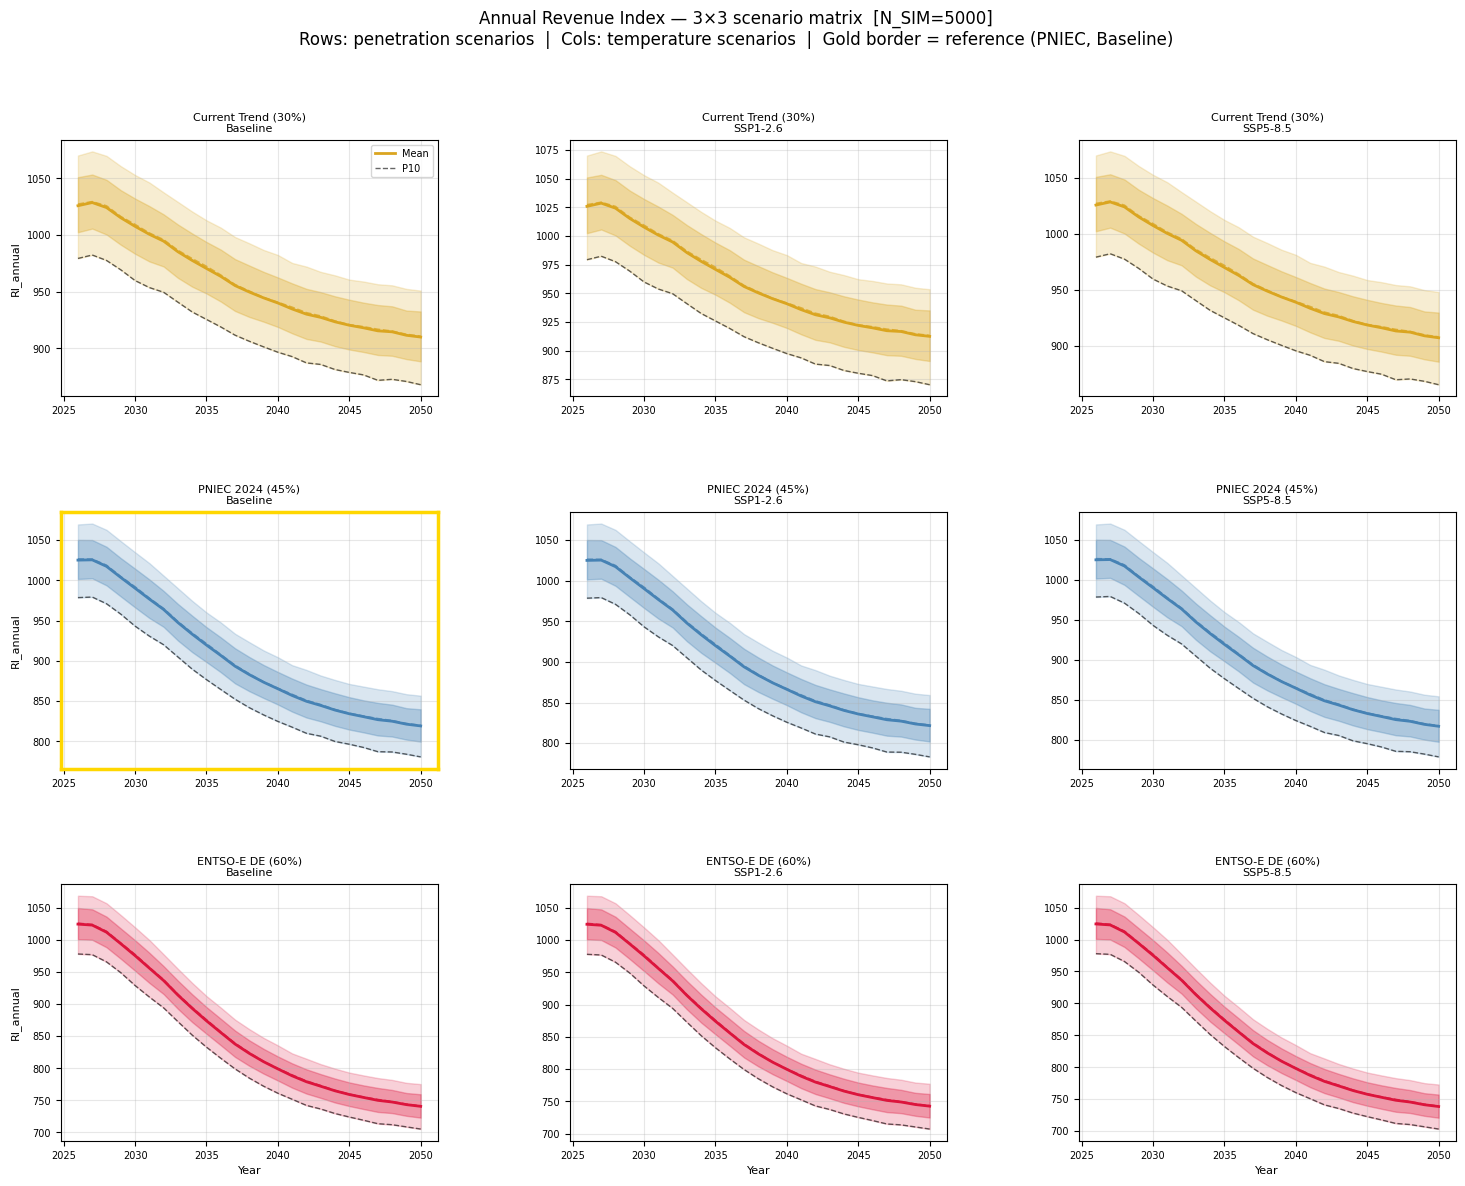

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 7: 3×3 fan chart grid ───────────────────────────────────")
 
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35)
 
for i, pen_key in enumerate(PEN_KEYS):
    for j, temp_key in enumerate(TEMP_KEYS):
        key  = (pen_key, temp_key)
        ax   = fig.add_subplot(gs[i, j])
        RI_m = df_metrics[
            (df_metrics["pen_scenario"]==pen_key) &
            (df_metrics["temp_scenario"]==temp_key)
        ].sort_values("year")
        color = PEN_COLORS[pen_key]
 
        ax.fill_between(RI_m["year"], RI_m["RI_p10"], RI_m["RI_p90"],
                        alpha=0.20, color=color)
        ax.fill_between(RI_m["year"], RI_m["RI_p25"], RI_m["RI_p75"],
                        alpha=0.30, color=color)
        ax.plot(RI_m["year"], RI_m["RI_mean"],  color=color, lw=2.0,
                label="Mean")
        ax.plot(RI_m["year"], RI_m["RI_p50"],   color=color, lw=1.2,
                ls="--", alpha=0.8)
        ax.plot(RI_m["year"], RI_m["RI_p10"],   color="black", lw=1.0,
                ls="--", alpha=0.6, label="P10")
 
        # reference border
        is_ref = (pen_key==REF_PEN and temp_key==REF_TEMP)
        if is_ref:
            for spine in ax.spines.values():
                spine.set_edgecolor("gold")
                spine.set_linewidth(2.5)
 
        ax.set_title(f"{PEN_LABELS[pen_key]}\n{TEMP_LABELS[temp_key]}",
                     fontsize=8)
        if i == 2: ax.set_xlabel("Year", fontsize=8)
        if j == 0: ax.set_ylabel("RI_annual", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)
        if i==0 and j==0:
            ax.legend(fontsize=7)
 
fig.suptitle(
    f"Annual Revenue Index — 3×3 scenario matrix  [N_SIM={N_SIM}]\n"
    f"Rows: penetration scenarios  |  Cols: temperature scenarios  |  "
    f"Gold border = reference (PNIEC, Baseline)",
    fontsize=12
)
plt.show()

> **Takeaway.** All nine panels narrow in relative terms toward 2050 as the mean level falls, and the reference cell (gold border) sits between the extremes on both axes -- confirming penetration and temperature move the distribution in the directions the scenario design intends.


── Step 8: Cross-scenario comparison ───────────────────────────


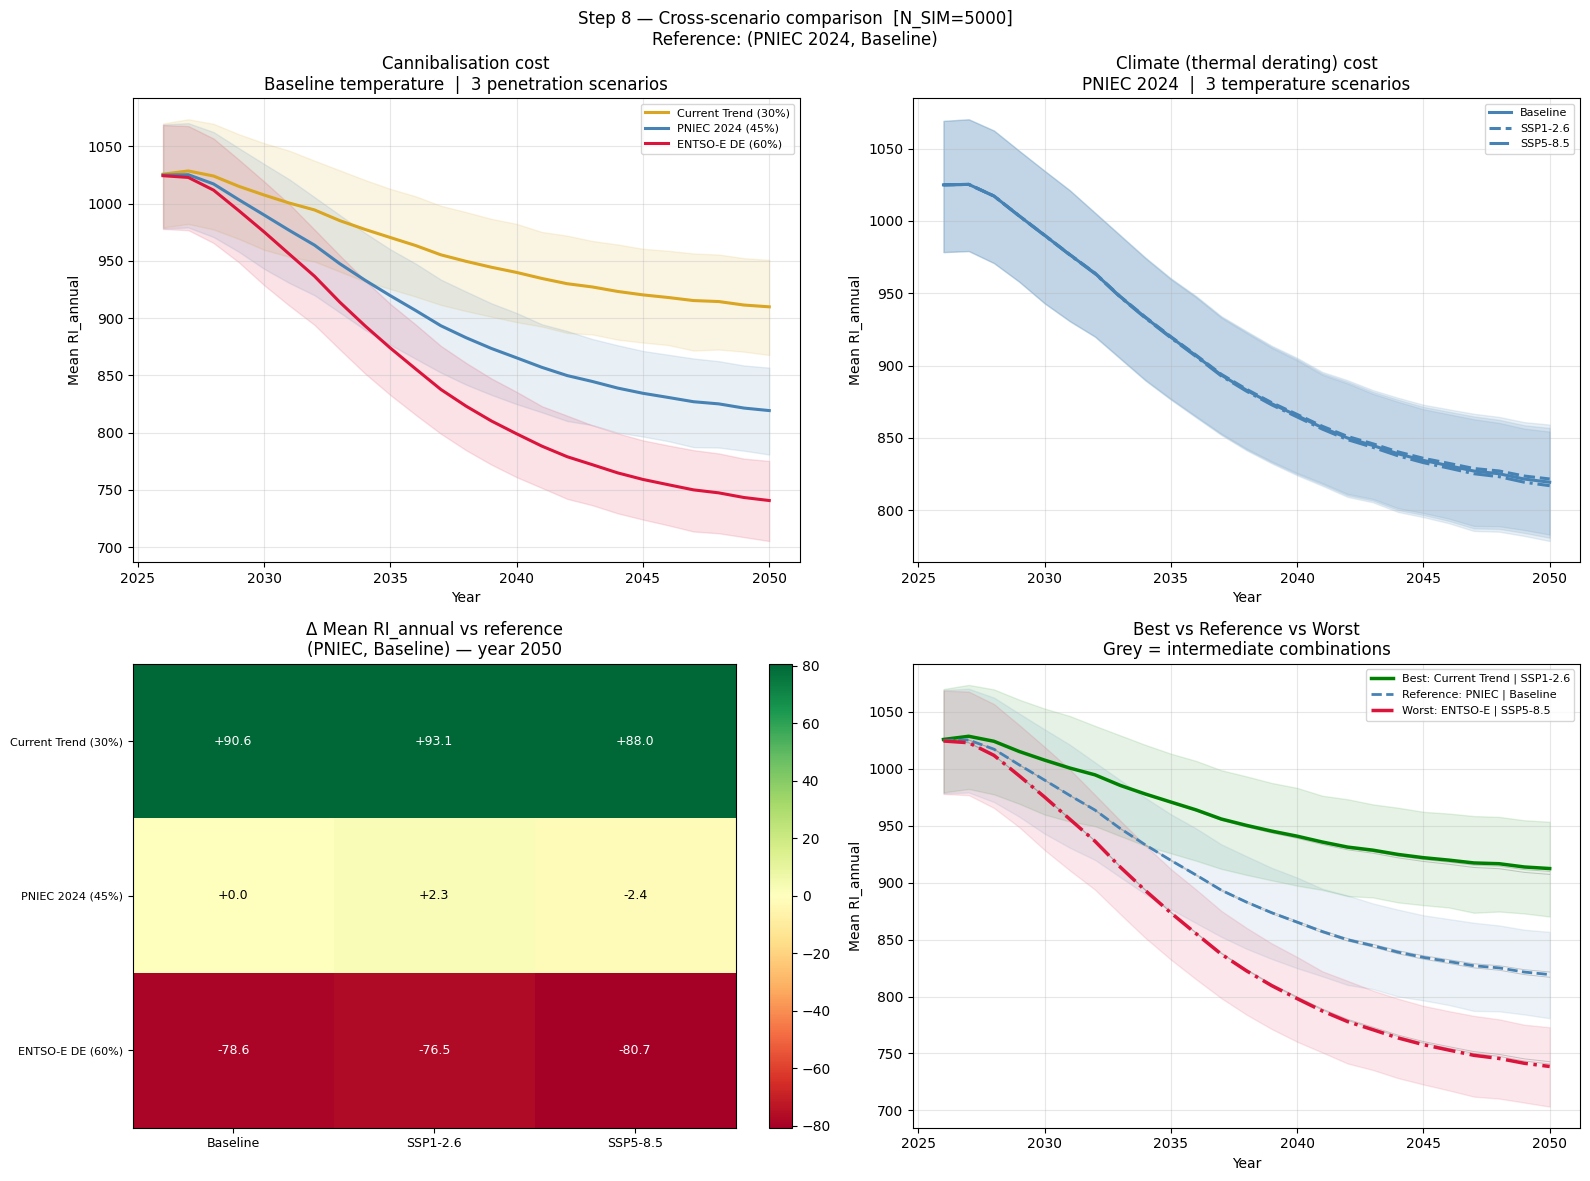

In [14]:
# STEP 8 — Cross-scenario comparison plots
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 8: Cross-scenario comparison ───────────────────────────")
 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
 
# ── top-left: cannibalisation cost (baseline temp, all pen scenarios) ─────────
ax = axes[0, 0]
for pen_key in PEN_KEYS:
    RI_m = df_metrics[
        (df_metrics["pen_scenario"]==pen_key) &
        (df_metrics["temp_scenario"]=="baseline")
    ].sort_values("year")
    ax.fill_between(RI_m["year"], RI_m["RI_p10"], RI_m["RI_p90"],
                    alpha=0.12, color=PEN_COLORS[pen_key])
    ax.plot(RI_m["year"], RI_m["RI_mean"],
            color=PEN_COLORS[pen_key], lw=2.2,
            label=PEN_LABELS[pen_key])
ax.set_title("Cannibalisation cost\nBaseline temperature  |  3 penetration scenarios")
ax.set_xlabel("Year"); ax.set_ylabel("Mean RI_annual")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
# ── top-right: climate cost (PNIEC pen, all temp scenarios) ───────────────────
ax = axes[0, 1]
for temp_key in TEMP_KEYS:
    RI_m = df_metrics[
        (df_metrics["pen_scenario"]=="pniec") &
        (df_metrics["temp_scenario"]==temp_key)
    ].sort_values("year")
    ax.fill_between(RI_m["year"], RI_m["RI_p10"], RI_m["RI_p90"],
                    alpha=0.12, color="steelblue")
    ax.plot(RI_m["year"], RI_m["RI_mean"],
            color="steelblue", lw=2.2, ls=TEMP_STYLES[temp_key],
            label=TEMP_LABELS[temp_key])
ax.set_title("Climate (thermal derating) cost\nPNIEC 2024  |  3 temperature scenarios")
ax.set_xlabel("Year"); ax.set_ylabel("Mean RI_annual")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
# ── bottom-left: heatmap of P10 in 2050 ──────────────────────────────────────
ax = axes[1, 0]
df_2050 = df_metrics[df_metrics["year"]==2050].copy()
heatmap = np.zeros((3, 3))
for i, pk in enumerate(PEN_KEYS):
    for j, tk in enumerate(TEMP_KEYS):
        row = df_2050[(df_2050["pen_scenario"]==pk) &
                      (df_2050["temp_scenario"]==tk)]
        heatmap[i, j] = float(row["delta_mean_vs_ref"].iloc[0])
 
im = ax.imshow(heatmap, cmap="RdYlGn", vmin=heatmap.min(),
               vmax=abs(heatmap.min()), aspect="auto")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels([TEMP_LABELS[k] for k in TEMP_KEYS], fontsize=9)
ax.set_yticklabels([PEN_LABELS[k]  for k in PEN_KEYS],  fontsize=8)
for i in range(3):
    for j in range(3):
        val = heatmap[i,j]
        ax.text(j, i, f"{val:+.1f}", ha="center", va="center",
                fontsize=9,
                color="white" if abs(val) > abs(heatmap.min())*0.5 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Δ Mean RI_annual vs reference\n(PNIEC, Baseline) — year 2050")
 
# ── bottom-right: best vs worst vs reference ──────────────────────────────────
ax = axes[1, 1]
best_key  = ("current_trend", "ssp126")
worst_key = ("entso_e",       "ssp585")
 
# faint grey lines for all intermediate
for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])
    if key in [best_key, worst_key, ref_key]:
        continue
    RI_m = df_metrics[
        (df_metrics["pen_scenario"]==comb["pen_key"]) &
        (df_metrics["temp_scenario"]==comb["temp_key"])
    ].sort_values("year")
    ax.plot(RI_m["year"], RI_m["RI_mean"],
            color="grey", lw=0.7, alpha=0.4)
 
for key, color, lw, ls, label in [
    (best_key,  "green",     2.5, "-",  "Best: Current Trend | SSP1-2.6"),
    (ref_key,   "steelblue", 2.0, "--", "Reference: PNIEC | Baseline"),
    (worst_key, "crimson",   2.5, "-.", "Worst: ENTSO-E | SSP5-8.5"),
]:
    RI_m = df_metrics[
        (df_metrics["pen_scenario"]==key[0]) &
        (df_metrics["temp_scenario"]==key[1])
    ].sort_values("year")
    ax.fill_between(RI_m["year"], RI_m["RI_p10"], RI_m["RI_p90"],
                    alpha=0.10, color=color)
    ax.plot(RI_m["year"], RI_m["RI_mean"],
            color=color, lw=lw, ls=ls, label=label)
 
ax.set_title("Best vs Reference vs Worst\nGrey = intermediate combinations")
ax.set_xlabel("Year"); ax.set_ylabel("Mean RI_annual")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
plt.suptitle(
    f"Step 8 — Cross-scenario comparison  [N_SIM={N_SIM}]\n"
    f"Reference: (PNIEC 2024, Baseline)",
    fontsize=12
)
plt.tight_layout()
plt.show()
 

> **Takeaway.** Penetration separates the nine scenarios far more than temperature does: the three penetration groups form visibly distinct bands, while the three temperature variants within each group sit close together.

  colour scale: 80 - 115 EUR/kWp (data 81.2 - 110.8), shared across all panels


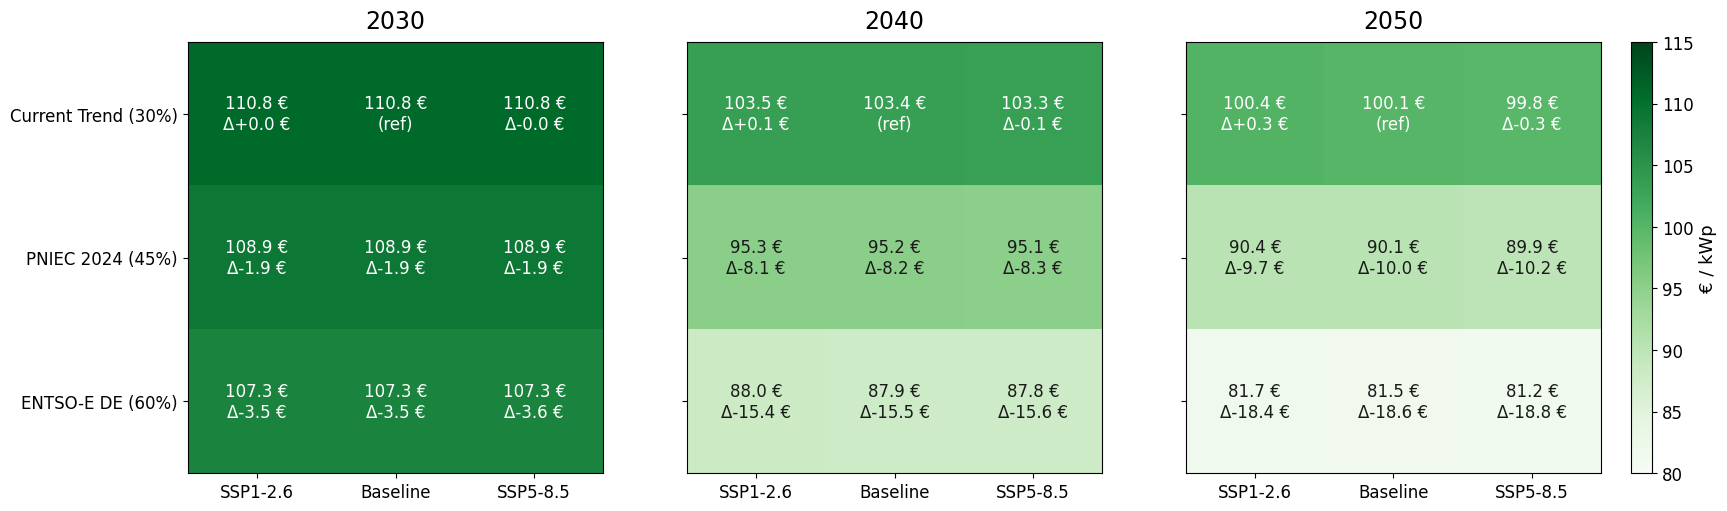

  2030: penetration range   3.5 EUR/kWp | temperature range 0.02 EUR/kWp | ratio 171.2x
  2040: penetration range  15.5 EUR/kWp | temperature range 0.19 EUR/kWp | ratio  81.9x
  2050: penetration range  18.6 EUR/kWp | temperature range 0.51 EUR/kWp | ratio  36.2x


In [15]:
# -- Heatmap: Mean Annual Revenue by scenario — 2030 / 2040 / 2050 --
#
# D7: colour limits are taken from the data across
# ALL THREE panels and shared between them, which is what makes the years
# comparable — a cell that is darker in 2030 than in 2050 really is worth more.
# Within 2030 the three penetration scenarios have barely separated yet, so that
# panel reads as almost uniform. That is the finding, not a scaling failure.
#
# A single-hue GREEN sequential ramp replaces RdYlGn: revenue is a magnitude,
# not a polarity, so it wants one hue running light-to-dark. RdYlGn also fails
# for red-green colour blindness, and its yellow midpoint implies a neutral
# point that has no meaning here.

YEARS_PLOT     = [2030, 2040, 2050]
TEMP_KEYS_PLOT = ["ssp126", "baseline", "ssp585"]   # SSP1-2.6 first — cool to warm

# ── build one 3x3 grid per year ──────────────────────────────────────────────
_grids = {}
for _y in YEARS_PLOT:
    _dy = df_metrics[df_metrics["year"] == _y]
    _g = np.zeros((3, 3))
    for _i, _pk in enumerate(PEN_KEYS):
        for _j, _tk in enumerate(TEMP_KEYS_PLOT):
            _r = _dy[(_dy["pen_scenario"] == _pk) & (_dy["temp_scenario"] == _tk)]
            _g[_i, _j] = float(_r["RI_mean"].iloc[0]) * MARKET_PRICE_EUR_MWH / 1000
    _grids[_y] = _g

_all  = np.concatenate([g.ravel() for g in _grids.values()])
_vmin = np.floor(_all.min() / 5) * 5
_vmax = np.ceil(_all.max() / 5) * 5
print(f"  colour scale: {_vmin:.0f} - {_vmax:.0f} EUR/kWp "
      f"(data {_all.min():.1f} - {_all.max():.1f}), shared across all panels")

_cmap = plt.get_cmap("Greens")
_ref_i = PEN_KEYS.index("current_trend")
_ref_j = TEMP_KEYS_PLOT.index("baseline")

fig, axes = plt.subplots(1, 3, figsize=(19, 5.6))

for _ax, _y in zip(axes, YEARS_PLOT):
    _g   = _grids[_y]
    _ref = _g[_ref_i, _ref_j]          # reference is Current Trend | Baseline OF THAT YEAR
    _im  = _ax.imshow(_g, cmap=_cmap, vmin=_vmin, vmax=_vmax, aspect="auto")

    _ax.set_xticks(range(3))
    _ax.set_xticklabels([TEMP_LABELS[k] for k in TEMP_KEYS_PLOT], fontsize=12)
    _ax.set_yticks(range(3))
    if _ax is axes[0]:
        _ax.set_yticklabels([PEN_LABELS[k] for k in PEN_KEYS], fontsize=12)
    else:
        _ax.set_yticklabels([])

    for _i in range(3):
        for _j in range(3):
            _v = _g[_i, _j]
            # ink flips to white on the dark end so every cell stays legible
            _txt = "white" if (_v - _vmin) / (_vmax - _vmin) > 0.55 else "#1a1a1a"
            if _i == _ref_i and _j == _ref_j:
                _lab = f"{_v:.1f} €\n(ref)"
            else:
                _lab = f"{_v:.1f} €\nΔ{_v - _ref:+.1f} €"
            _ax.text(_j, _i, _lab, ha="center", va="center", fontsize=12,
                     color=_txt, multialignment="center")

    _ax.set_title(f"{_y}", fontsize=17, pad=10)


_cbar = fig.colorbar(_im, ax=axes, fraction=0.020, pad=0.02)
_cbar.ax.tick_params(labelsize=12)
_cbar.set_label("€ / kWp", fontsize=13)

fig.patch.set_facecolor("white")

plt.show()

# the asymmetry the grid is meant to expose, stated numerically
for _y in YEARS_PLOT:
    _g = _grids[_y]
    _pen  = _g.mean(axis=1).max() - _g.mean(axis=1).min()
    _temp = _g.mean(axis=0).max() - _g.mean(axis=0).min()
    print(f"  {_y}: penetration range {_pen:5.1f} EUR/kWp | "
          f"temperature range {_temp:4.2f} EUR/kWp | ratio {_pen/_temp:5.1f}x")

> **Takeaway.** Revenue falls from 2030 to 2050 in every scenario, and the shared colour scale makes the year-over-year decline comparable across panels; the printed penetration-vs-temperature range ratio below confirms penetration is the dominant axis at every horizon shown.

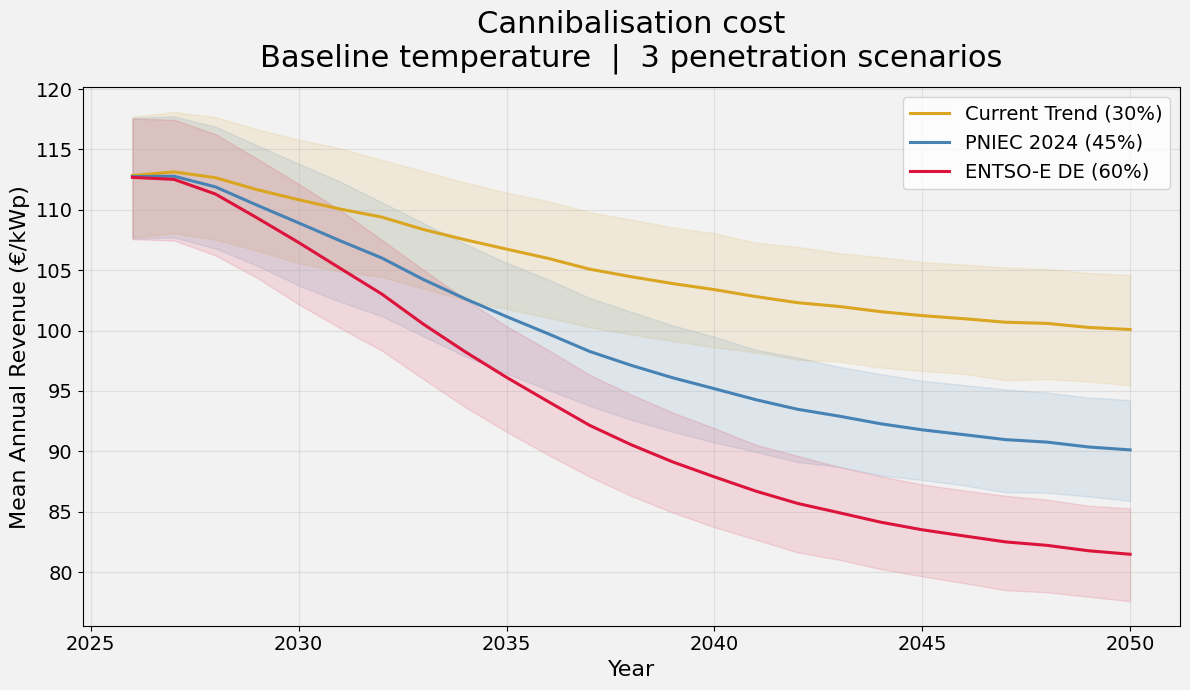

In [16]:
# -- Standalone: Cannibalisation cost — Revenue (Baseline temperature) --

fig, ax = plt.subplots(figsize=(12, 7))

for pen_key in PEN_KEYS:
    RI_m = df_metrics[
        (df_metrics["pen_scenario"] == pen_key) &
        (df_metrics["temp_scenario"] == "baseline")
    ].sort_values("year")
    rev_mean = RI_m["RI_mean"] * MARKET_PRICE_EUR_MWH / 1000
    rev_p10  = RI_m["RI_p10"]  * MARKET_PRICE_EUR_MWH / 1000
    rev_p90  = RI_m["RI_p90"]  * MARKET_PRICE_EUR_MWH / 1000
    ax.fill_between(RI_m["year"], rev_p10, rev_p90,
                    alpha=0.12, color=PEN_COLORS[pen_key])
    ax.plot(RI_m["year"], rev_mean,
            color=PEN_COLORS[pen_key], lw=2.2,
            label=PEN_LABELS[pen_key])

ax.set_title("Cannibalisation cost\nBaseline temperature  |  3 penetration scenarios",
             fontsize=22, pad=15)
ax.set_xlabel("Year", fontsize=16)
ax.set_ylabel("Mean Annual Revenue (€/kWp)", fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.legend(fontsize=14)
ax.grid(alpha=0.3)

fig.patch.set_facecolor("#F2F2F2")
ax.set_facecolor("#F2F2F2")

plt.tight_layout()
plt.show()

> **Takeaway.** The revenue gap between penetration scenarios widens over the horizon, consistent with the fan-chart and heatmap views above -- this isolates that one comparison for the thesis figure.


── Step 9: Waterfall decomposition (2050 P10) ───────────────────
  P10 best case   (Current Trend | SSP1-2.6) :   870.23
  Penetration effect  (Current→ENTSO-E)      :  -162.96
  Climate effect      (SSP126→SSP585)         :    -4.91
  Interaction effect  (joint)                 :    +0.91
  P10 worst case  (ENTSO-E | SSP5-8.5)       :   703.27
  Check (should = 0): +0.000000


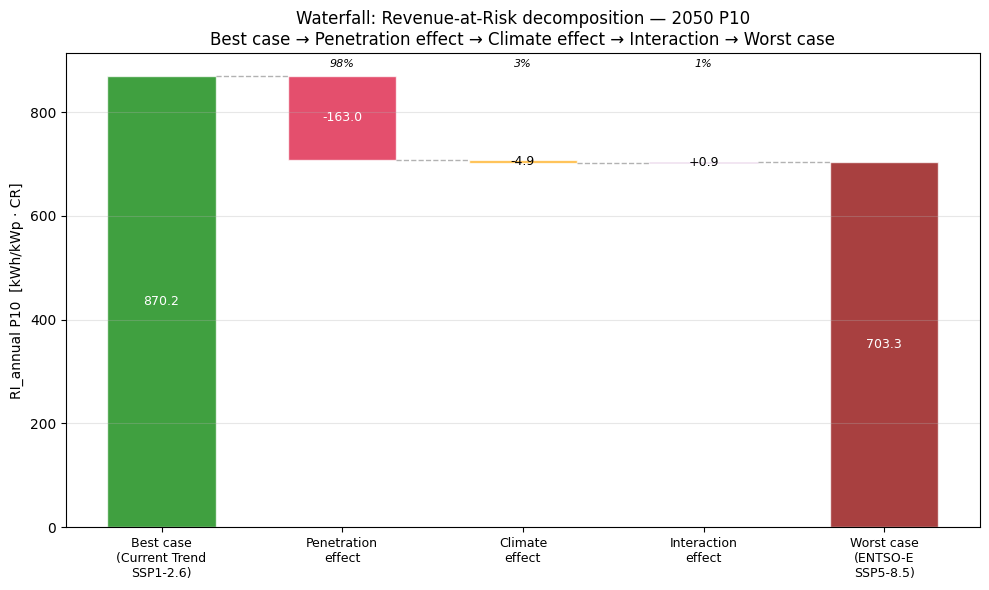


── Multi-scenario Revenue Index complete ────────────────────────
  Combinations : 9
  Saved        : risk_metrics_summary.parquet
                 ri_annual_results_multiscenario.parquet
  Reference    : (pniec, baseline)

  2050 P10 range: 870.2 (best) → 703.3 (worst)  Δ=-167.0
  Penetration drives 98% of gap
  Climate drives     3% of gap
  Interaction        1% of gap


In [17]:
# STEP 9 — Waterfall decomposition of Revenue-at-Risk (P10) in 2050
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 9: Waterfall decomposition (2050 P10) ───────────────────")
 
# P10 values for decomposition
def get_p10(pen_key, temp_key, year=2050):
    return float(df_metrics[
        (df_metrics["pen_scenario"]==pen_key) &
        (df_metrics["temp_scenario"]==temp_key) &
        (df_metrics["year"]==year)
    ]["RI_p10"].iloc[0])
 
p10_best      = get_p10("current_trend", "ssp126")   # best case
p10_pen_shock = get_p10("entso_e",       "ssp126")   # add pen shock only
p10_clim_shock= get_p10("current_trend", "ssp585")   # add climate shock only
p10_worst     = get_p10("entso_e",       "ssp585")   # worst case
 
# decomposition
penetration_effect = p10_pen_shock - p10_best
climate_effect     = p10_clim_shock - p10_best
interaction_effect = p10_worst - p10_best - penetration_effect - climate_effect
 
print(f"  P10 best case   (Current Trend | SSP1-2.6) : {p10_best:>8.2f}")
print(f"  Penetration effect  (Current→ENTSO-E)      : {penetration_effect:>+8.2f}")
print(f"  Climate effect      (SSP126→SSP585)         : {climate_effect:>+8.2f}")
print(f"  Interaction effect  (joint)                 : {interaction_effect:>+8.2f}")
print(f"  P10 worst case  (ENTSO-E | SSP5-8.5)       : {p10_worst:>8.2f}")
print(f"  Check (should = 0): "
      f"{p10_best+penetration_effect+climate_effect+interaction_effect-p10_worst:+.6f}")
 
# waterfall chart
fig, ax = plt.subplots(figsize=(10, 6))
categories = ["Best case\n(Current Trend\nSSP1-2.6)",
              "Penetration\neffect",
              "Climate\neffect",
              "Interaction\neffect",
              "Worst case\n(ENTSO-E\nSSP5-8.5)"]
values     = [p10_best,
              penetration_effect,
              climate_effect,
              interaction_effect,
              p10_worst]
colors_wf  = ["green", "crimson", "orange", "purple", "darkred"]
running    = p10_best
 
bars_bottom = [0, p10_best, p10_best+penetration_effect,
               p10_best+penetration_effect+climate_effect, 0]
bars_height = [p10_best,
               penetration_effect,
               climate_effect,
               interaction_effect,
               p10_worst]
 
for xi, (bot, hgt, col, cat) in enumerate(
        zip(bars_bottom, bars_height, colors_wf, categories)):
    ax.bar(xi, abs(hgt), bottom=min(bot, bot+hgt),
           color=col, alpha=0.75, width=0.6, edgecolor="white")
    # connector lines
    if xi < 4:
        next_bot = bars_bottom[xi+1]
        ax.plot([xi+0.3, xi+0.7], [bot+hgt, bot+hgt],
                color="grey", lw=1.0, ls="--", alpha=0.6)
    # value annotation
    val_y = min(bot, bot+hgt) + abs(hgt)/2
    ax.text(xi, val_y, f"{hgt:+.1f}" if xi not in [0,4] else f"{abs(hgt):.1f}",
            ha="center", va="center", fontsize=9,
            color="white" if abs(hgt) > 20 else "black")
 
ax.set_xticks(range(5))
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylabel("RI_annual P10  [kWh/kWp · CR]")
ax.set_title(
    f"Waterfall: Revenue-at-Risk decomposition — 2050 P10\n"
    f"Best case → Penetration effect → Climate effect → "
    f"Interaction → Worst case"
)
ax.grid(alpha=0.3, axis="y")
 
# pct annotations
total_gap = abs(p10_worst - p10_best)
if total_gap > 0:
    for xi, (val, label) in enumerate([
        (penetration_effect, "pen"),
        (climate_effect,     "clim"),
        (interaction_effect, "int"),
    ], start=1):
        pct = abs(val) / total_gap * 100
        ax.text(xi, ax.get_ylim()[1]*0.97, f"{pct:.0f}%",
                ha="center", fontsize=8, color="black",
                style="italic")
 
plt.tight_layout()
plt.show()
 
print(f"\n── Multi-scenario Revenue Index complete ────────────────────────")
print(f"  Combinations : {len(COMBINATIONS)}")
print(f"  Saved        : {out_metrics.name}")
print(f"                 {out_annual.name}")
print(f"  Reference    : ({REF_PEN}, {REF_TEMP})")
print(f"\n  2050 P10 range: {p10_best:.1f} (best) → {p10_worst:.1f} (worst)  "
      f"Δ={p10_worst-p10_best:+.1f}")
print(f"  Penetration drives {abs(penetration_effect)/total_gap*100:.0f}% of gap")
print(f"  Climate drives     {abs(climate_effect)/total_gap*100:.0f}% of gap")
print(f"  Interaction        {abs(interaction_effect)/total_gap*100:.0f}% of gap")

> **Takeaway.** The waterfall attributes most of the 2050 P10 gap between scenarios to the penetration axis, with temperature contributing a smaller, partially offsetting share -- consistent with the cross-scenario comparison above.

  Cumulative and NPV arrays computed for 9 combinations
  Reference cumulative mean : 22572.2
  Reference NPV mean        : 11673.8  (r=7%)


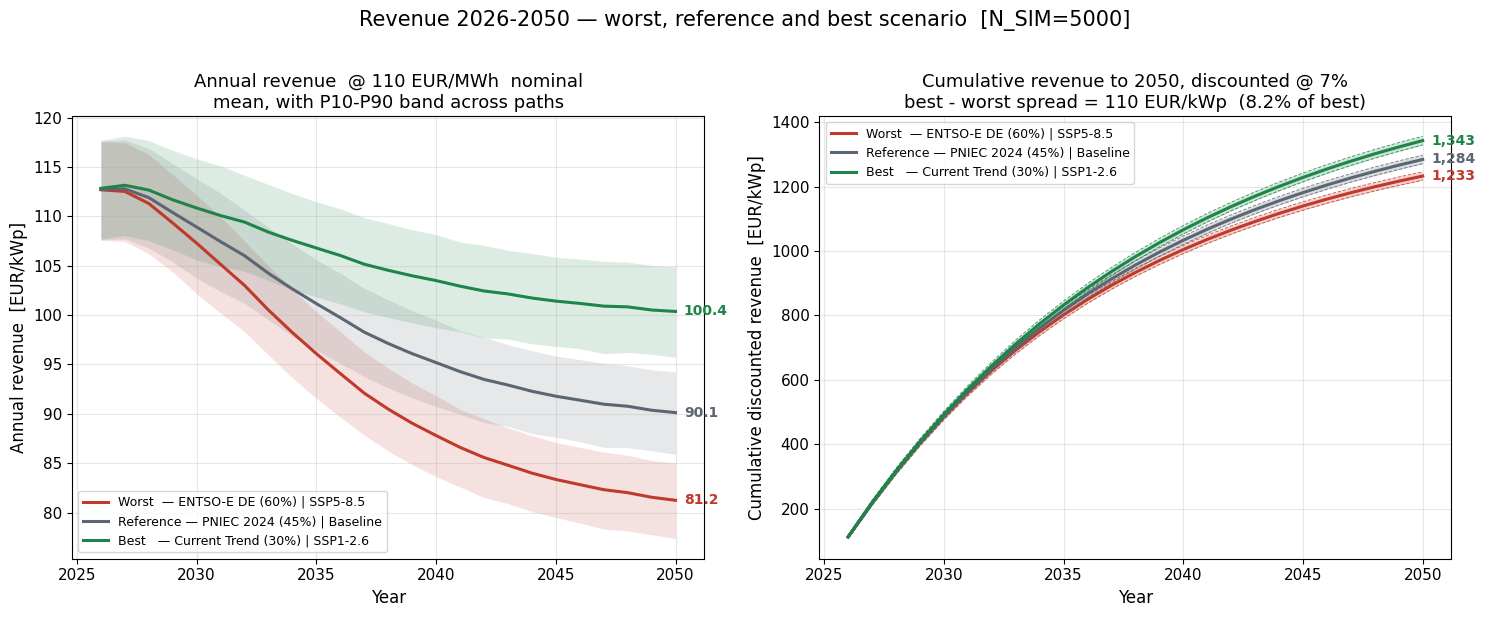


  Cumulative RI 2026-2050 (undiscounted):
  Scenario                                             mean         P10      d mean
  ---------------------------------------------  ----------  ----------  ----------
  Current Trend (30%) | Baseline                    23987.1     23765.2     +1415.0
  Current Trend (30%) | SSP1-2.6                    24009.2     23787.2     +1437.1
  Current Trend (30%) | SSP5-8.5                    23963.7     23742.2     +1391.5
  PNIEC 2024 (45%) | Baseline                       22572.2     22362.7        +0.0
  PNIEC 2024 (45%) | SSP1-2.6                       22592.3     22382.6       +20.2
  PNIEC 2024 (45%) | SSP5-8.5                       22550.7     22341.5       -21.4
  ENTSO-E DE (60%) | Baseline                       21326.9     21128.7     -1245.3
  ENTSO-E DE (60%) | SSP1-2.6                       21345.4     21147.1     -1226.8
  ENTSO-E DE (60%) | SSP5-8.5                       21307.2     21109.2     -1264.9

  NPV-equivalent (r=7%):
  Curre

In [18]:
# ── Annual and cumulative revenue — worst / reference / best ─────────────────
#
# Three scenarios instead of all nine. The 3x3 heatmap already shows every cell;
# what this figure has to do is show the SHAPE over time, and nine near-parallel
# lines (six of which differ only by an invisible temperature effect) obscure
# that. Worst and best are the extreme corners of the grid, reference is the
# model's designated (PNIEC, Baseline) case.
#
# Colours are a diverging trio around the reference — red for the worst corner,
# neutral grey for the reference, green for the best — because the three are
# ORDERED, not merely different.
#
# DISCOUNTING. The right panel accumulates DISCOUNTED revenue at DISCOUNT_RATE,
# so its endpoint is the NPV in npv_cum and the panel reads as the NPV building
# up year by year. This matters for the headline: the scenarios diverge mostly
# after 2040, exactly where discounting bites hardest, so the undiscounted
# spread (409 EUR/kWp, 15.6% of best) overstates the valuation impact — the
# discounted spread is roughly 153 EUR/kWp, 11.4%.
#
# The LEFT panel stays nominal on purpose: it shows what the plant earns in each
# year, and discounting it would mix the cannibalisation decline together with
# the discount curve in one line. Set DISCOUNT_ANNUAL_PANEL = True to change it.
#
# BAND VISIBILITY on the right. The P10-P90 band is only ~28 EUR/kWp wide at
# 2050 against an axis spanning ~1400, so at full scale it is a hairline. That
# is the real result — 25 years of weather diversify away, leaving cumulative
# uncertainty at ~2% of level while the scenario gap is 5.5x the band — but a
# band nobody can see reads as a band nobody drew, so it carries dashed
# P10/P90 edges. The width is reported numerically below the figure rather
# than zoomed into: 4.2% of level in 2030, 2.5% in 2040, 2.1% in 2050.

DISCOUNT_RATE = 0.07   # 7% WACC
_P = MARKET_PRICE_EUR_MWH / 1000.0

DISCOUNT_ANNUAL_PANEL = False   # left panel: nominal (False) or discounted (True)

# discount factor per year, base year = first simulated year
_disc = np.array([(1 + DISCOUNT_RATE) ** -(yr - years_unique[0])
                  for yr in years_unique])

cumulative = {}
npv_cum    = {}

for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])

    # undiscounted cumulative sum per path (N_SIM,)
    cumulative[key] = RI_annual[key].sum(axis=1)

    # NPV-equivalent
    npv = np.zeros(N_SIM)
    for yi, yr in enumerate(years_unique):
        t   = yr - years_unique[0]
        npv += RI_annual[key][:, yi] / (1 + DISCOUNT_RATE) ** t
    npv_cum[key] = npv

ref_cum = cumulative[ref_key]
ref_npv = npv_cum[ref_key]

print(f"  Cumulative and NPV arrays computed for {len(COMBINATIONS)} combinations")
print(f"  Reference cumulative mean : {ref_cum.mean():.1f}")
print(f"  Reference NPV mean        : {ref_npv.mean():.1f}  (r={DISCOUNT_RATE:.0%})")

# ── the three scenarios to draw ──────────────────────────────────────────────
BEST_KEY  = ("current_trend", "ssp126")
WORST_KEY = ("entso_e",       "ssp585")

SHOW = [
    (WORST_KEY, "#c0392b", "Worst  — ENTSO-E DE (60%) | SSP5-8.5"),
    (ref_key,   "#5c6672", "Reference — PNIEC 2024 (45%) | Baseline"),
    (BEST_KEY,  "#1e8449", "Best   — Current Trend (30%) | SSP1-2.6"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── left: ANNUAL revenue ─────────────────────────────────────────────────────
ax = axes[0]
for _key, _c, _lab in SHOW:
    _ann = RI_annual[_key] * _P                      # (N_SIM, n_years) in EUR/kWp
    if DISCOUNT_ANNUAL_PANEL:
        _ann = _ann * _disc[np.newaxis, :]
    _m   = _ann.mean(axis=0)
    _p10, _p90 = np.percentile(_ann, [10, 90], axis=0)
    ax.fill_between(years_unique, _p10, _p90, color=_c, alpha=0.15, lw=0)
    ax.plot(years_unique, _m, color=_c, lw=2.2, label=_lab)
    ax.annotate(f"{_m[-1]:.1f}", xy=(years_unique[-1], _m[-1]),
                xytext=(6, 0), textcoords="offset points",
                fontsize=10, color=_c, va="center", fontweight="bold")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual revenue  [EUR/kWp]", fontsize=12)
_ttl = (f"Annual revenue  @ {MARKET_PRICE_EUR_MWH} EUR/MWh"
        + (f"  discounted @ {DISCOUNT_RATE:.0%}" if DISCOUNT_ANNUAL_PANEL
           else "  nominal") + chr(10)
        + "mean, with P10-P90 band across paths")
ax.set_title(_ttl, fontsize=13)
ax.tick_params(axis="both", labelsize=11)
ax.legend(fontsize=9, loc="lower left")
ax.grid(alpha=0.3)

# ── right: CUMULATIVE revenue to 2050 ────────────────────────────────────────
ax = axes[1]
for _key, _c, _lab in SHOW:
    # discounted revenue, accumulated along the year axis per path — the final
    # column equals npv_cum[_key] * _P by construction (asserted below)
    _cum = np.cumsum(RI_annual[_key] * _P * _disc[np.newaxis, :], axis=1)
    _m   = _cum.mean(axis=0)
    _p10, _p90 = np.percentile(_cum, [10, 90], axis=0)
    ax.fill_between(years_unique, _p10, _p90, color=_c, alpha=0.22, lw=0)
    ax.plot(years_unique, _p10, color=_c, lw=0.7, ls="--", alpha=0.8)
    ax.plot(years_unique, _p90, color=_c, lw=0.7, ls="--", alpha=0.8)
    ax.plot(years_unique, _m, color=_c, lw=2.2, label=_lab)
    ax.annotate(f"{_m[-1]:,.0f}", xy=(years_unique[-1], _m[-1]),
                xytext=(6, 0), textcoords="offset points",
                fontsize=10, color=_c, va="center", fontweight="bold")

_best_end  = (npv_cum[BEST_KEY]  * _P).mean()
_worst_end = (npv_cum[WORST_KEY] * _P).mean()

# the panel and the NPV table must agree — they are the same quantity
_check = np.cumsum(RI_annual[BEST_KEY] * _P * _disc[np.newaxis, :], axis=1)[:, -1].mean()
assert abs(_check - _best_end) < 1e-6, \
    f"discounted cumsum endpoint {_check:.4f} != npv_cum {_best_end:.4f}"
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Cumulative discounted revenue  [EUR/kWp]", fontsize=12)
_ttl = (f"Cumulative revenue to 2050, discounted @ {DISCOUNT_RATE:.0%}" + chr(10)
        + f"best - worst spread = {_best_end - _worst_end:,.0f} EUR/kWp"
        + f"  ({100*(_best_end - _worst_end)/_best_end:.1f}% of best)")
ax.set_title(_ttl, fontsize=13)
ax.tick_params(axis="both", labelsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)

fig.suptitle(f"Revenue 2026-2050 — worst, reference and best scenario  "
             f"[N_SIM={N_SIM}]", fontsize=15, y=1.02)
fig.patch.set_facecolor("white")
plt.tight_layout()

plt.show()

# ── summary statistics ────────────────────────────────────────────────────────
print(f"\n  Cumulative RI 2026-2050 (undiscounted):")
print(f"  {'Scenario':<45}  {'mean':>10}  {'P10':>10}  {'d mean':>10}")
print(f"  {'-'*45}  {'-'*10}  {'-'*10}  {'-'*10}")
for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])
    cum = cumulative[key]
    print(f"  {comb['label'][:45]:<45}  "
          f"{cum.mean():>10.1f}  "
          f"{np.percentile(cum,10):>10.1f}  "
          f"{cum.mean()-ref_cum.mean():>+10.1f}")

print(f"\n  NPV-equivalent (r={DISCOUNT_RATE:.0%}):")
for comb in COMBINATIONS:
    key = (comb["pen_key"], comb["temp_key"])
    npv = npv_cum[key]
    print(f"  {comb['label'][:45]:<45}  "
          f"NPV={npv.mean():>8.1f}  "
          f"d={npv.mean()-ref_npv.mean():>+8.1f}")

print(f"\n  Cumulative discounted band width (P10-P90, % of level):")
for _key, _c, _lab in SHOW:
    _cum = np.cumsum(RI_annual[_key] * _P * _disc[np.newaxis, :], axis=1)
    _q10, _q50, _q90 = np.percentile(_cum, [10, 50, 90], axis=0)
    _w = [100 * (_q90[years_unique.index(y)] - _q10[years_unique.index(y)])
          / _q50[years_unique.index(y)] for y in (2030, 2040, 2050)]
    print(f"  {_lab:<42} 2030 {_w[0]:4.2f}%   2040 {_w[1]:4.2f}%   2050 {_w[2]:4.2f}%")

print(f"\n  Revenue in EUR/kWp @ {MARKET_PRICE_EUR_MWH} EUR/MWh:")
for _key, _c, _lab in SHOW:
    _c_eur = cumulative[_key] * _P
    _n_eur = npv_cum[_key] * _P
    print(f"  {_lab:<42} cumulative {_c_eur.mean():>8,.1f}  "
          f"NPV {_n_eur.mean():>8,.1f}")

> **Takeaway.** The three trajectories separate early and the gap compounds through the cumulative and NPV panels; by 2050 the worst case's cumulative shortfall against the reference is the single largest number this notebook reports.

### Risk analysis


── VaR and CVaR analysis — 2050 ─────────────────────────────

  Scenario                                 Mean       Std    VaR10%    CVaR10%     VaR5%    CVaR5%     VaR1%    CVaR1%
  -----------------------------------  --------  --------  --------  ---------  --------  --------  --------  --------
  Reference (PNIEC, Baseline)            819.27     30.08    780.88     764.58    768.97    753.65    744.41    729.70
  Best case (Current Trend, SSP1-2.6)    912.40     32.97    870.23     852.55    857.02    840.76    830.88    814.96
  Worst case (ENTSO-E, SSP5-8.5)         738.54     27.64    703.27     688.17    692.39    677.91    668.12    654.91

  ✓ ES10 (Step 5) == CVaR_0.1 (here) for reference scenario @ 2050: 764.58

  Loss vs reference mean  (ref mean = 819.27):
  Scenario                             VaR10 loss   CVaR10 loss   VaR5 loss  CVaR5 loss
  -----------------------------------  ----------  ------------  ----------  ----------
  Reference (PNIEC, Baseline)            

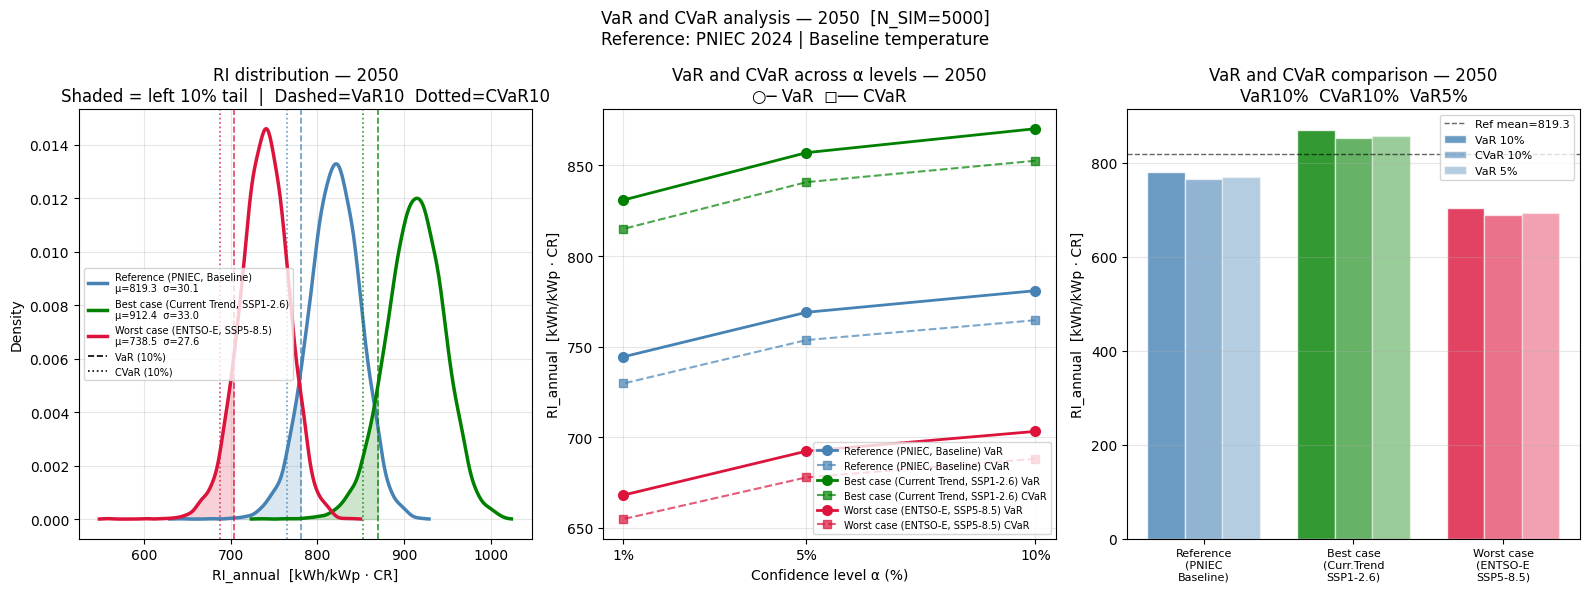

In [19]:
# ── VaR and CVaR analysis — 2050 distribution ────────────────────────────────
# Three scenarios: reference (PNIEC, Baseline), best (Current Trend, SSP1-2.6),
# worst (ENTSO-E, SSP5-8.5)
#
# VaR(α)  = P(α) of the annual RI distribution
#           the revenue level NOT exceeded with probability α
# CVaR(α) = E[RI | RI ≤ P(α)]
#           expected revenue in the worst α% of outcomes
# VaR_a / CVaR_a below are stored as RAW REVENUE LEVELS (not losses).
# Losses relative to the reference mean are derived separately below,
# for display only (‘Loss vs reference mean’ block).
# NOTE: CVaR_0.1 here is the same statistic as ES10 in Step 5 (mean of the
# tail below P10) — cross-checked against df_metrics right after this loop.

YEAR_ANALYSIS = 2050
yi_2050       = list(years_unique).index(YEAR_ANALYSIS)
ALPHA_LEVELS  = [0.10, 0.05, 0.01]   # 10%, 5%, 1% tail

scenarios_analysis = {
    "Reference\n(PNIEC, Baseline)":       ref_key,
    "Best case\n(Current Trend, SSP1-2.6)": ("current_trend", "ssp126"),
    "Worst case\n(ENTSO-E, SSP5-8.5)":      ("entso_e",       "ssp585"),
}
colors_analysis = {
    "Reference\n(PNIEC, Baseline)":         "steelblue",
    "Best case\n(Current Trend, SSP1-2.6)": "green",
    "Worst case\n(ENTSO-E, SSP5-8.5)":      "crimson",
}

# ── compute VaR and CVaR ──────────────────────────────────────────────────────
results_risk = {}

print(f"\n── VaR and CVaR analysis — {YEAR_ANALYSIS} ─────────────────────────────")
print(f"\n  {'Scenario':<35}  {'Mean':>8}  {'Std':>8}  "
      f"{'VaR10%':>8}  {'CVaR10%':>9}  "
      f"{'VaR5%':>8}  {'CVaR5%':>8}  "
      f"{'VaR1%':>8}  {'CVaR1%':>8}")
print(f"  {'-'*35}  {'-'*8}  {'-'*8}  "
      f"{'-'*8}  {'-'*9}  "
      f"{'-'*8}  {'-'*8}  "
      f"{'-'*8}  {'-'*8}")

for label, key in scenarios_analysis.items():
    ri  = RI_annual[key][:, yi_2050]
    res = {"mean": ri.mean(), "std": ri.std(), "paths": ri}

    for alpha in ALPHA_LEVELS:
        var_val  = float(np.percentile(ri, alpha * 100))
        cvar_val = float(ri[ri <= var_val].mean())
        res[f"VaR_{alpha}"]  = var_val
        res[f"CVaR_{alpha}"] = cvar_val

    results_risk[label] = res

    # print one row
    clean = label.replace("\n", " ")
    print(f"  {clean:<35}  "
          f"{res['mean']:>8.2f}  "
          f"{res['std']:>8.2f}  "
          f"{res['VaR_0.1']:>8.2f}  "
          f"{res['CVaR_0.1']:>9.2f}  "
          f"{res['VaR_0.05']:>8.2f}  "
          f"{res['CVaR_0.05']:>8.2f}  "
          f"{res['VaR_0.01']:>8.2f}  "
          f"{res['CVaR_0.01']:>8.2f}")

# ── cross-check: CVaR_0.1 (this cell) vs ES10 (Step 5, df_metrics) ───────────
# Same formula (mean of the tail below P10) computed independently in two
# places; this assertion keeps them from silently drifting apart.
_ref_label = list(scenarios_analysis.keys())[0]
_es10_ref = df_metrics.loc[
    (df_metrics["pen_scenario"] == ref_key[0]) &
    (df_metrics["temp_scenario"] == ref_key[1]) &
    (df_metrics["year"] == YEAR_ANALYSIS),
    "ES10",
].iloc[0]
_cvar10_ref = results_risk[_ref_label]["CVaR_0.1"]
assert abs(_es10_ref - _cvar10_ref) < 1e-6, (
    f"ES10 (Step 5) and CVaR_0.1 (this cell) disagree for the reference "
    f"scenario at {YEAR_ANALYSIS}: {_es10_ref:.4f} vs {_cvar10_ref:.4f} "
    "(they are supposed to be the identical statistic)."
)
print(f"\n  ✓ ES10 (Step 5) == CVaR_0.1 (here) for reference scenario "
      f"@ {YEAR_ANALYSIS}: {_es10_ref:.2f}")

# ── VaR and CVaR loss relative to reference mean ─────────────────────────────
ref_mean = results_risk[list(scenarios_analysis.keys())[0]]["mean"]
print(f"\n  Loss vs reference mean  (ref mean = {ref_mean:.2f}):")
print(f"  {'Scenario':<35}  {'VaR10 loss':>10}  {'CVaR10 loss':>12}  "
      f"{'VaR5 loss':>10}  {'CVaR5 loss':>10}")
print(f"  {'-'*35}  {'-'*10}  {'-'*12}  {'-'*10}  {'-'*10}")
for label, res in results_risk.items():
    clean = label.replace("\n", " ")
    print(f"  {clean:<35}  "
          f"{ref_mean - res['VaR_0.1']:>+10.2f}  "
          f"{ref_mean - res['CVaR_0.1']:>+12.2f}  "
          f"{ref_mean - res['VaR_0.05']:>+10.2f}  "
          f"{ref_mean - res['CVaR_0.05']:>+10.2f}")

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── left: distribution overlay with VaR and CVaR markers ─────────────────────
ax = axes[0]
for label, res in results_risk.items():
    ri    = res["paths"]
    color = colors_analysis[label]
    x_kde = np.linspace(ri.min() - 10, ri.max() + 10, 400)
    kde   = gaussian_kde(ri)
    ax.plot(x_kde, kde(x_kde), color=color, lw=2.5,
            label=label.replace("\n"," ") +
                  f"\nμ={ri.mean():.1f}  σ={ri.std():.1f}")
    ax.fill_between(x_kde, kde(x_kde),
                    where=x_kde <= res["VaR_0.1"],
                    alpha=0.20, color=color)

    # VaR10 and CVaR10 markers
    ax.axvline(res["VaR_0.1"], color=color, lw=1.2, ls="--", alpha=0.8)
    ax.axvline(res["CVaR_0.1"], color=color, lw=1.2, ls=":", alpha=0.8)

# legend for line styles
ax.plot([], [], "k--", lw=1.2, label="VaR (10%)")
ax.plot([], [], "k:",  lw=1.2, label="CVaR (10%)")
ax.set_xlabel(f"RI_annual  [kWh/kWp · CR]")
ax.set_ylabel("Density")
ax.set_title(f"RI distribution — {YEAR_ANALYSIS}\n"
             f"Shaded = left 10% tail  |  Dashed=VaR10  Dotted=CVaR10")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ── middle: VaR across alpha levels ──────────────────────────────────────────
ax = axes[1]
alpha_pct = [a * 100 for a in ALPHA_LEVELS]
for label, res in results_risk.items():
    color  = colors_analysis[label]
    var_vals  = [res[f"VaR_{a}"]  for a in ALPHA_LEVELS]
    cvar_vals = [res[f"CVaR_{a}"] for a in ALPHA_LEVELS]
    ax.plot(alpha_pct, var_vals,  "o-", color=color, lw=2.0, ms=7,
            label=label.replace("\n"," ") + " VaR")
    ax.plot(alpha_pct, cvar_vals, "s--", color=color, lw=1.5, ms=6,
            alpha=0.7, label=label.replace("\n"," ") + " CVaR")

ax.set_xlabel("Confidence level α (%)")
ax.set_ylabel("RI_annual  [kWh/kWp · CR]")
ax.set_title(f"VaR and CVaR across α levels — {YEAR_ANALYSIS}\n"
             f"○─ VaR  ◻── CVaR")
ax.set_xticks(alpha_pct)
ax.set_xticklabels([f"{a:.0f}%" for a in alpha_pct])
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ── right: CVaR10 comparison bar chart ───────────────────────────────────────
ax = axes[2]
labels_short = ["Reference\n(PNIEC\nBaseline)",
                "Best case\n(Curr.Trend\nSSP1-2.6)",
                "Worst case\n(ENTSO-E\nSSP5-8.5)"]
x        = np.arange(3)
width    = 0.25
metrics  = [("VaR 10%",  "VaR_0.1",  0.8),
             ("CVaR 10%", "CVaR_0.1", 0.6),
             ("VaR 5%",   "VaR_0.05", 0.4)]

for mi, (metric_label, metric_key, alpha_bar) in enumerate(metrics):
    vals = [list(results_risk.values())[si][metric_key]
            for si in range(3)]
    colors_bar = [list(colors_analysis.values())[si]
                  for si in range(3)]
    bars = ax.bar(x + mi*width - width, vals,
                  width=width,
                  color=colors_bar,
                  alpha=alpha_bar,
                  label=metric_label,
                  edgecolor="white")

ax.axhline(ref_mean, color="black", lw=1.0, ls="--",
           alpha=0.6, label=f"Ref mean={ref_mean:.1f}")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, fontsize=8)
ax.set_ylabel("RI_annual  [kWh/kWp · CR]")
ax.set_title(f"VaR and CVaR comparison — {YEAR_ANALYSIS}\n"
             f"VaR10%  CVaR10%  VaR5%")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

plt.suptitle(
    f"VaR and CVaR analysis — {YEAR_ANALYSIS}  [N_SIM={N_SIM}]\n"
    f"Reference: PNIEC 2024 | Baseline temperature",
    fontsize=12
)
plt.tight_layout()
plt.show()

> **Takeaway.** The worst-case scenario's CVaR sits well below its VaR in absolute terms and below the reference and best-case CVaRs, showing tail risk grows faster than the central estimate as penetration and temperature both worsen.

### Variance decomposition

In [20]:
# ── Approach 1: log-variance decomposition ────────────────────────────────────
YEAR_DECOMP = 2050
yi = list(years_unique).index(YEAR_DECOMP)

for label, key in scenarios_analysis.items():
    ri   = RI_annual[key][:, yi]
    p    = P_annual[key][:, yi]
    cr   = CR_annual[key][:, yi]

    # log-variance decomposition (joint mask: all three positive)
    _mask  = (ri > 0) & (p > 0) & (cr > 0)
    log_ri = np.log(ri[_mask])
    log_p  = np.log(p[_mask])
    log_cr = np.log(cr[_mask])

    var_log_p  = np.var(log_p,  ddof=1)
    var_log_cr = np.var(log_cr, ddof=1)
    cov_p_cr   = np.cov(log_p, log_cr)[0, 1]
    var_log_ri = np.var(log_ri, ddof=1)

    # percentage attributions
    pct_p    = var_log_p  / var_log_ri * 100
    pct_cr   = var_log_cr / var_log_ri * 100
    pct_cov  = 2 * cov_p_cr / var_log_ri * 100

    print(f"\n  {label.replace(chr(10),' ')}")
    print(f"    Var[log P]   = {var_log_p:.5f}  ({pct_p:.1f}%)")
    print(f"    Var[log CR]  = {var_log_cr:.5f}  ({pct_cr:.1f}%)")
    print(f"    2·Cov(P,CR)  = {2*cov_p_cr:.5f}  ({pct_cov:.1f}%)")
    print(f"    Total        = {var_log_ri:.5f}  (100%)")


  Reference (PNIEC, Baseline)
    Var[log P]   = 0.00126  (92.1%)
    Var[log CR]  = 0.00028  (20.8%)
    2·Cov(P,CR)  = -0.00025  (-18.7%)
    Total        = 0.00136  (100%)

  Best case (Current Trend, SSP1-2.6)
    Var[log P]   = 0.00126  (95.1%)
    Var[log CR]  = 0.00023  (17.4%)
    2·Cov(P,CR)  = -0.00023  (-17.4%)
    Total        = 0.00132  (100%)

  Worst case (ENTSO-E, SSP5-8.5)
    Var[log P]   = 0.00126  (88.5%)
    Var[log CR]  = 0.00035  (24.5%)
    2·Cov(P,CR)  = -0.00028  (-19.8%)
    Total        = 0.00142  (100%)


In [21]:
# ── Approach 2: daily-level 3-way decomposition (GHI, temperature, CR) ────
# Approach 1 above splits RI_annual into P and CR — but P itself is a
# product, P(t) = (GHI_sim(t)/G_STC)*f_temp(t)*PR, so it bundles solar
# irradiance and temperature together. This splits P into those two parts.
#
# This is done at the DAILY level, not annual: RI(t) = GHI(t)/G_STC *
# f_temp(t) * PR * CR(t) is an EXACT product for a single day, so
# log RI(t) = log GHI(t) + log f_temp(t) + log CR(t) + const holds exactly.
# (Approach 1's annual version is only approximate, since RI_annual =
# sum_t[P(t)*CR(t)] is not exactly P_annual*CR_annual when P and CR
# co-vary within the year — which they do, per the cannibalisation effect
# discussed elsewhere in this notebook.)
#
# f_temp(t) is recovered from the stored P(t) array rather than
# recomputed, so it is numerically identical to what actually went into P:
# f_temp(t) = P(t) / (GHI_sim(t)/G_STC * PR)

for label, key in scenarios_analysis.items():
    pen_key, temp_key = key
    m = years_arr == YEAR_DECOMP

    ghi_day    = GHI_sim[:, m]
    p_day      = P_temp[temp_key][:, m]
    cr_day     = CR_sim_pen[pen_key][:, m]
    f_temp_day = p_day / (ghi_day / G_STC * PR)
    ri_day     = p_day * cr_day

    _mask = (ghi_day > 0) & (f_temp_day > 0) & (cr_day > 0) & (ri_day > 0)
    log_ghi = np.log(ghi_day[_mask])
    log_ft  = np.log(f_temp_day[_mask])
    log_cr  = np.log(cr_day[_mask])
    log_ri  = np.log(ri_day[_mask])

    var_ghi = np.var(log_ghi, ddof=1)
    var_ft  = np.var(log_ft,  ddof=1)
    var_cr  = np.var(log_cr,  ddof=1)
    cov_ghi_ft = np.cov(log_ghi, log_ft)[0, 1]
    cov_ghi_cr = np.cov(log_ghi, log_cr)[0, 1]
    cov_ft_cr  = np.cov(log_ft,  log_cr)[0, 1]
    var_ri_direct = np.var(log_ri, ddof=1)
    var_ri_sum = (var_ghi + var_ft + var_cr
                  + 2 * cov_ghi_ft + 2 * cov_ghi_cr + 2 * cov_ft_cr)

    print(f"\n  {label.replace(chr(10), ' ')}  (n={_mask.sum():,} sim-days, {YEAR_DECOMP})")
    print(f"    Var[log GHI]         = {var_ghi:>9.5f}  ({var_ghi/var_ri_direct*100:>5.1f}%)")
    print(f"    Var[log f_temp]      = {var_ft:>9.5f}  ({var_ft/var_ri_direct*100:>5.1f}%)")
    print(f"    Var[log CR]          = {var_cr:>9.5f}  ({var_cr/var_ri_direct*100:>5.1f}%)")
    print(f"    2*Cov(GHI, f_temp)   = {2*cov_ghi_ft:>9.5f}  ({2*cov_ghi_ft/var_ri_direct*100:>5.1f}%)")
    print(f"    2*Cov(GHI, CR)       = {2*cov_ghi_cr:>9.5f}  ({2*cov_ghi_cr/var_ri_direct*100:>5.1f}%)")
    print(f"    2*Cov(f_temp, CR)    = {2*cov_ft_cr:>9.5f}  ({2*cov_ft_cr/var_ri_direct*100:>5.1f}%)")
    print(f"    Sum of above         = {var_ri_sum:>9.5f}  (100%)")
    print(f"    Var[log RI] (direct) = {var_ri_direct:>9.5f}  "
          f"(check: |Delta|={abs(var_ri_sum - var_ri_direct):.2e})")


  Reference (PNIEC, Baseline)  (n=1,824,648 sim-days, 2050)
    Var[log GHI]         =   0.63734  (108.9%)
    Var[log f_temp]      =   0.00295  (  0.5%)
    Var[log CR]          =   0.01055  (  1.8%)
    2*Cov(GHI, f_temp)   =  -0.06494  (-11.1%)
    2*Cov(GHI, CR)       =   0.00172  (  0.3%)
    2*Cov(f_temp, CR)    =  -0.00217  ( -0.4%)
    Sum of above         =   0.58545  (100%)
    Var[log RI] (direct) =   0.58545  (check: |Delta|=4.69e-08)



  Best case (Current Trend, SSP1-2.6)  (n=1,824,764 sim-days, 2050)
    Var[log GHI]         =   0.63733  (109.2%)
    Var[log f_temp]      =   0.00293  (  0.5%)
    Var[log CR]          =   0.00860  (  1.5%)
    2*Cov(GHI, f_temp)   =  -0.06477  (-11.1%)
    2*Cov(GHI, CR)       =   0.00152  (  0.3%)
    2*Cov(f_temp, CR)    =  -0.00195  ( -0.3%)
    Sum of above         =   0.58366  (100%)
    Var[log RI] (direct) =   0.58366  (check: |Delta|=9.88e-08)



  Worst case (ENTSO-E, SSP5-8.5)  (n=1,824,502 sim-days, 2050)
    Var[log GHI]         =   0.63735  (108.5%)
    Var[log f_temp]      =   0.00296  (  0.5%)
    Var[log CR]          =   0.01275  (  2.2%)
    2*Cov(GHI, f_temp)   =  -0.06511  (-11.1%)
    2*Cov(GHI, CR)       =   0.00193  (  0.3%)
    2*Cov(f_temp, CR)    =  -0.00241  ( -0.4%)
    Sum of above         =   0.58748  (100%)
    Var[log RI] (direct) =   0.58748  (check: |Delta|=4.60e-08)


### Simulated against historical

The historical benchmark is read from `03_revenue_index_historical.ipynb`. The daily comparisons below reconstruct the observed daily index through the same shared production chain, with the same seasonal uplift the simulation uses -- a like-for-like comparison, since a scalar annual-mean uplift on the historical side only would understate summer derating there and bias the comparison.

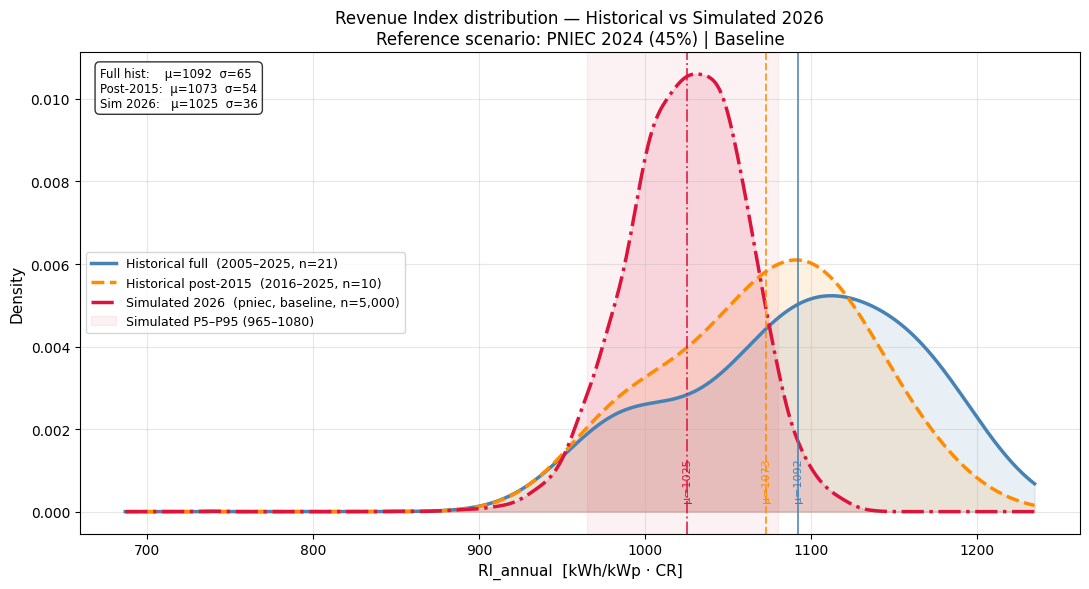


  Full hist   : μ=1092.4  σ=65.0  range=[981, 1185]
  Post-2015   : μ=1072.7  σ=54.0  range=[983, 1161]
  Sim 2026    : μ=1025.0  σ=35.8  P5=964.7  P95=1080.3


In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde, t as t_dist

# ── configuration ─────────────────────────────────────────────────────────────
POST_YEAR  = 2015   # "post-2015" structural break (change as needed)
SIM_YEAR   = 2026
SIM_PEN    = REF_PEN    # "pniec"
SIM_TEMP   = REF_TEMP   # "baseline"

# ── data slices ───────────────────────────────────────────────────────────────
# load df_hist if not already in scope
_hist_path = data_results / "ri_annual_results_hist.parquet"
if "df_hist" not in dir() or not isinstance(df_hist, pd.DataFrame):
    df_hist = pd.read_parquet(_hist_path)

ri_full   = df_hist["RI_annual"].dropna().values
ri_post   = df_hist.loc[df_hist["year"] > POST_YEAR, "RI_annual"].dropna().values
ri_sim    = df_annual.loc[
    (df_annual["pen_scenario"]  == SIM_PEN)  &
    (df_annual["temp_scenario"] == SIM_TEMP) &
    (df_annual["year"]          == SIM_YEAR),
    "RI_annual"
].values

# ── KDE curves ────────────────────────────────────────────────────────────────
x_min = min(ri_full.min(), ri_sim.min()) - 50
x_max = max(ri_full.max(), ri_sim.max()) + 50
x_grid = np.linspace(x_min, x_max, 500)

kde_full = gaussian_kde(ri_full,  bw_method="scott")
kde_post = gaussian_kde(ri_post,  bw_method="scott")
kde_sim  = gaussian_kde(ri_sim,   bw_method="scott")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(x_grid, kde_full(x_grid), color="steelblue",  lw=2.5,
        label=f"Historical full  (2005–2025, n={len(ri_full)})")
ax.fill_between(x_grid, kde_full(x_grid), alpha=0.12, color="steelblue")

ax.plot(x_grid, kde_post(x_grid), color="darkorange", lw=2.5, ls="--",
        label=f"Historical post-{POST_YEAR}  ({POST_YEAR+1}–2025, n={len(ri_post)})")
ax.fill_between(x_grid, kde_post(x_grid), alpha=0.12, color="darkorange")

ax.plot(x_grid, kde_sim(x_grid),  color="crimson",    lw=2.5, ls="-.",
        label=f"Simulated {SIM_YEAR}  ({SIM_PEN}, {SIM_TEMP}, n={len(ri_sim):,})")
ax.fill_between(x_grid, kde_sim(x_grid),  alpha=0.12, color="crimson")

# mean vertical lines
for ri, color, ls in [
    (ri_full, "steelblue",  "-"),
    (ri_post, "darkorange", "--"),
    (ri_sim,  "crimson",    "-."),
]:
    ax.axvline(ri.mean(), color=color, lw=1.4, ls=ls, alpha=0.8)
    ax.text(ri.mean(), ax.get_ylim()[1] * 0.02,
            f"μ={ri.mean():.0f}", color=color, fontsize=8,
            ha="center", va="bottom", rotation=90)

# percentile markers for simulated
p5_sim  = float(np.percentile(ri_sim, 5))
p95_sim = float(np.percentile(ri_sim, 95))
ax.axvspan(p5_sim, p95_sim, alpha=0.06, color="crimson",
           label=f"Simulated P5–P95 ({p5_sim:.0f}–{p95_sim:.0f})")

ax.set_xlabel("RI_annual  [kWh/kWp · CR]", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(
    f"Revenue Index distribution — Historical vs Simulated {SIM_YEAR}\n"
    f"Reference scenario: {PEN_LABELS[SIM_PEN]} | {TEMP_LABELS[SIM_TEMP]}",
    fontsize=12
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# stats box
_stats = (
    f"Full hist:    μ={ri_full.mean():.0f}  σ={ri_full.std():.0f}\n"
    f"Post-{POST_YEAR}:  μ={ri_post.mean():.0f}  σ={ri_post.std():.0f}\n"
    f"Sim {SIM_YEAR}:   μ={ri_sim.mean():.0f}  σ={ri_sim.std():.0f}"
)
ax.text(0.02, 0.97, _stats, transform=ax.transAxes,
        fontsize=8.5, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n  Full hist   : μ={ri_full.mean():.1f}  σ={ri_full.std():.1f}  "
      f"range=[{ri_full.min():.0f}, {ri_full.max():.0f}]")
print(f"  Post-{POST_YEAR}   : μ={ri_post.mean():.1f}  σ={ri_post.std():.1f}  "
      f"range=[{ri_post.min():.0f}, {ri_post.max():.0f}]")
print(f"  Sim {SIM_YEAR}    : μ={ri_sim.mean():.1f}  σ={ri_sim.std():.1f}  "
      f"P5={p5_sim:.1f}  P95={p95_sim:.1f}")

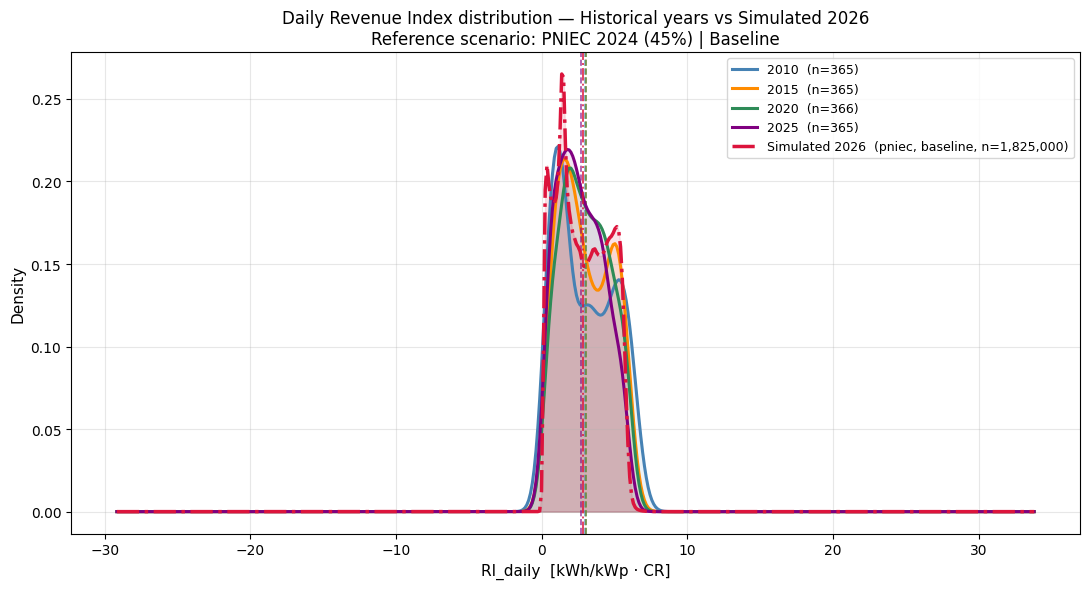

  Daily RI by calendar year:
    2010: n=365  mean=2.99  std=1.95
    2015: n=365  mean=3.02  std=1.71
    2020: n=366  mean=3.02  std=1.61
    2025: n=365  mean=2.71  std=1.54
    Sim 2026: n=1,825,000  mean=2.81  std=1.67


In [23]:
# ── daily RI distribution — specific historical years vs simulated 2026 ──
# Unlike the annual comparison above (one RI_annual point per calendar year,
# ~21 points total), this reconstructs the DAILY historical RI(t) series so
# each single year (2010/2015/2020/2025) has its own within-year distribution
# to compare against the simulated daily distribution for SIM_YEAR.
YEARS_HIST = [2010, 2015, 2020, 2025]

df_cr_d  = pd.read_parquet(data_modelled / "df_cr_modelled.parquet",
                            columns=["date", "year", "capture_rate"])
df_sol_d = pd.read_parquet(data_modelled / "df_solar_modelled.parquet") \
             .reset_index()[["date", "GHI_obs"]].rename(columns={"GHI_obs": "ghi_sum"})
df_tmp_d = pd.read_parquet(data_modelled / "df_temperature_modeled.parquet",
                            columns=["date", "t2m_mean"])
for _df in (df_cr_d, df_sol_d, df_tmp_d):
    _df["date"] = pd.to_datetime(_df["date"])

df_daily_hist = df_cr_d.merge(df_sol_d, on="date", how="left").merge(df_tmp_d, on="date", how="inner")
# Seasonal uplift by day-of-year, matching what the simulated side uses.
# A scalar annual mean here understates summer derating on the historical
# series only, which is not a like-for-like comparison.
_upl_hist = uplift_for_calendar(uplift_by_doy, df_daily_hist["date"].dt.dayofyear.values)
df_daily_hist["P_daily"] = production_chain(
    df_daily_hist["ghi_sum"].values, df_daily_hist["t2m_mean"].values, _upl_hist)["P"]
df_daily_hist["RI_daily"] = df_daily_hist["P_daily"] * df_daily_hist["capture_rate"]

ri_by_year = {
    yr: df_daily_hist.loc[df_daily_hist["year"] == yr, "RI_daily"].dropna().values
    for yr in YEARS_HIST
}

# simulated daily RI for SIM_YEAR (reuses SIM_PEN/SIM_TEMP/SIM_YEAR from the cell above)
_mask_sim    = years_arr == SIM_YEAR
ri_sim_daily = (P_temp[SIM_TEMP][:, _mask_sim] * CR_sim_pen[SIM_PEN][:, _mask_sim]).ravel()

# ── KDE plot ──
YEAR_COLORS = {2010: "steelblue", 2015: "darkorange", 2020: "seagreen", 2025: "purple"}

x_min = min(min(v.min() for v in ri_by_year.values()), ri_sim_daily.min()) - 20
x_max = max(max(v.max() for v in ri_by_year.values()), ri_sim_daily.max()) + 20
x_grid = np.linspace(x_min, x_max, 500)

fig, ax = plt.subplots(figsize=(11, 6))

for yr, vals in ri_by_year.items():
    kde = gaussian_kde(vals, bw_method="scott")
    ax.plot(x_grid, kde(x_grid), color=YEAR_COLORS[yr], lw=2.2, label=f"{yr}  (n={len(vals)})")
    ax.fill_between(x_grid, kde(x_grid), alpha=0.10, color=YEAR_COLORS[yr])
    ax.axvline(vals.mean(), color=YEAR_COLORS[yr], lw=1.2, ls="--", alpha=0.7)

kde_sim = gaussian_kde(ri_sim_daily, bw_method="scott")
ax.plot(x_grid, kde_sim(x_grid), color="crimson", lw=2.5, ls="-.",
        label=f"Simulated {SIM_YEAR}  ({SIM_PEN}, {SIM_TEMP}, n={len(ri_sim_daily):,})")
ax.fill_between(x_grid, kde_sim(x_grid), alpha=0.12, color="crimson")
ax.axvline(ri_sim_daily.mean(), color="crimson", lw=1.4, ls="-.", alpha=0.8)

ax.set_xlabel("RI_daily  [kWh/kWp · CR]", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(
    f"Daily Revenue Index distribution — Historical years vs Simulated {SIM_YEAR}\n"
    f"Reference scenario: {PEN_LABELS[SIM_PEN]} | {TEMP_LABELS[SIM_TEMP]}",
    fontsize=12
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("  Daily RI by calendar year:")
for yr, vals in ri_by_year.items():
    print(f"    {yr}: n={len(vals)}  mean={vals.mean():.2f}  std={vals.std():.2f}")
print(f"    Sim {SIM_YEAR}: n={len(ri_sim_daily):,}  mean={ri_sim_daily.mean():.2f}  std={ri_sim_daily.std():.2f}")

> **Takeaway.** The simulated 2026 daily distribution sits close to the most recent historical years and away from the earliest ones, consistent with the historical benchmark notebook's own downward trend in observed capture rate.

  Historical post-2015 : n=3,653  μ=3.972  σ=2.399
  Historical post-2021 : n=1,461  μ=3.098  σ=1.763
  Sim 2026 [current_trend]: n=1,825,000  μ=2.753  σ=1.644  (pen÷=1.022)


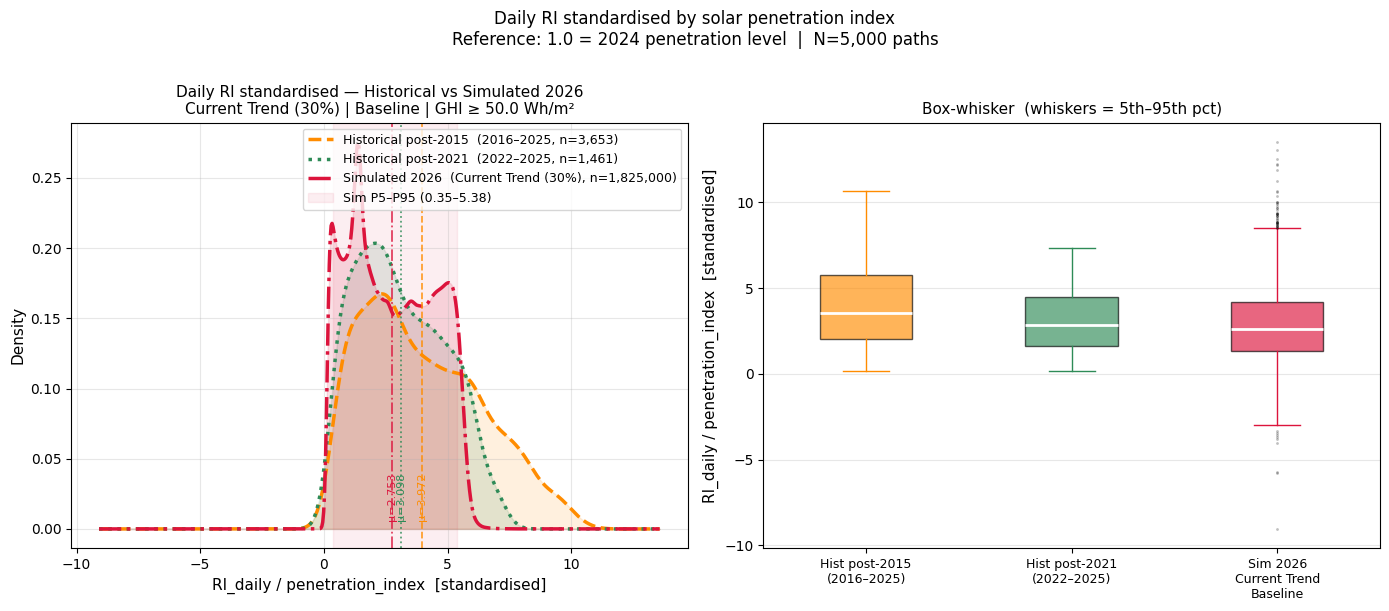

In [24]:
# daily RI distribution (historical vs simulated) 

# ── configuration ─────────────────────────────────────────────────────────────
POST_YEAR_1     = 2015
POST_YEAR_2     = 2021
SIM_YEAR_DAILY  = 2026
SIM_PEN_DAILY   = "current_trend"
SIM_TEMP_DAILY  = "baseline"
MIN_GHI         = 50.0

PEN_COL = {"current_trend": "pen_current_trend",
           "pniec":         "pen_pniec",
           "entso_e":       "pen_entso_e"}

# ── 1. HISTORICAL DAILY RI ────────────────────────────────────────────────────
df_cr_d  = pd.read_parquet(
    data_modelled / "df_cr_modelled.parquet",
    columns=["date","year","capture_rate","penetration_index"]
)
df_sol_d = pd.read_parquet(
    data_modelled / "df_solar_modelled.parquet",
).reset_index()[["date","GHI_obs"]].rename(columns={"GHI_obs": "ghi_sum"})
df_tmp_d = pd.read_parquet(
    data_modelled / "df_temperature_modeled.parquet",
    columns=["date","t2m_mean"]
)
df_cr_d["date"]  = pd.to_datetime(df_cr_d["date"])
df_sol_d["date"] = pd.to_datetime(df_sol_d["date"])
df_tmp_d["date"] = pd.to_datetime(df_tmp_d["date"])

df_daily_h = df_cr_d.merge(df_sol_d, on="date", how="left").merge(df_tmp_d, on="date", how="inner")

# Seasonal uplift by day-of-year, as on the simulated side.
_upl_h = uplift_for_calendar(uplift_by_doy, df_daily_h["date"].dt.dayofyear.values)
df_daily_h["P_daily"] = production_chain(
    df_daily_h["ghi_sum"].values, df_daily_h["t2m_mean"].values, _upl_h)["P"]
df_daily_h["RI_daily"] = df_daily_h["P_daily"] * df_daily_h["capture_rate"]
df_daily_h["RI_std"]   = df_daily_h["RI_daily"] / df_daily_h["penetration_index"]
df_daily_h = df_daily_h[df_daily_h["ghi_sum"] >= MIN_GHI].copy()

ri_hist_post1 = df_daily_h.loc[df_daily_h["year"] > POST_YEAR_1, "RI_std"].values
ri_hist_post2 = df_daily_h.loc[df_daily_h["year"] > POST_YEAR_2, "RI_std"].values

# ── 2. SIMULATED 2026 — current_trend + baseline ──────────────────────────────
df_pen = pd.read_parquet(
    Path("../../Data/Cleaned/df_penetration_scenarios.parquet"),
    columns=["date", PEN_COL[SIM_PEN_DAILY]]
)
df_pen["date"] = pd.to_datetime(df_pen["date"])
_pen_vals  = df_pen[df_pen["date"].dt.year == SIM_YEAR_DAILY].reset_index(drop=True)[PEN_COL[SIM_PEN_DAILY]].values

_mask_2026 = years_arr == SIM_YEAR_DAILY
_RI_2d     = P_temp[SIM_TEMP_DAILY][:, _mask_2026] * CR_sim_pen[SIM_PEN_DAILY][:, _mask_2026]
_RI_std    = _RI_2d / _pen_vals[np.newaxis, :]
_active    = GHI_sim[:, _mask_2026] >= MIN_GHI
ri_sim_d   = _RI_std[_active]

# ── 3. STATS ──────────────────────────────────────────────────────────────────
print(f"  Historical post-{POST_YEAR_1} : n={len(ri_hist_post1):,}  "
      f"μ={ri_hist_post1.mean():.3f}  σ={ri_hist_post1.std():.3f}")
print(f"  Historical post-{POST_YEAR_2} : n={len(ri_hist_post2):,}  "
      f"μ={ri_hist_post2.mean():.3f}  σ={ri_hist_post2.std():.3f}")
print(f"  Sim {SIM_YEAR_DAILY} [{SIM_PEN_DAILY}]: n={len(ri_sim_d):,}  "
      f"μ={ri_sim_d.mean():.3f}  σ={ri_sim_d.std():.3f}  "
      f"(pen÷={_pen_vals.mean():.3f})")

# ── 4. KDE ────────────────────────────────────────────────────────────────────
_all_vals = np.concatenate([ri_hist_post1, ri_sim_d])
x_grid_d  = np.linspace(_all_vals.min() - 0.05, _all_vals.max() + 0.05, 600)

_series = [
    (ri_hist_post1, "darkorange", "--",
     f"Historical post-{POST_YEAR_1}  ({POST_YEAR_1+1}–2025, n={len(ri_hist_post1):,})"),
    (ri_hist_post2, "seagreen",   ":",
     f"Historical post-{POST_YEAR_2}  ({POST_YEAR_2+1}–2025, n={len(ri_hist_post2):,})"),
    (ri_sim_d,      "crimson",    "-.",
     f"Simulated {SIM_YEAR_DAILY}  ({PEN_LABELS[SIM_PEN_DAILY]}, n={len(ri_sim_d):,})"),
]

# ── 5. PLOT ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for ri_d, color, ls, label in _series:
    kde = gaussian_kde(ri_d, bw_method="scott")
    ax.plot(x_grid_d, kde(x_grid_d), color=color, lw=2.5, ls=ls, label=label)
    ax.fill_between(x_grid_d, kde(x_grid_d), alpha=0.13, color=color)

_y_top = max(gaussian_kde(ri_d, bw_method="scott")(x_grid_d).max()
             for ri_d, *_ in _series)
for ri_d, color, ls, _ in _series:
    ax.axvline(ri_d.mean(), color=color, lw=1.3, ls=ls, alpha=0.8)
    ax.text(ri_d.mean(), _y_top * 0.02, f"μ={ri_d.mean():.3f}",
            color=color, fontsize=8, ha="center", va="bottom", rotation=90)

_p5  = float(np.percentile(ri_sim_d,  5))
_p95 = float(np.percentile(ri_sim_d, 95))
ax.axvspan(_p5, _p95, alpha=0.07, color="crimson",
           label=f"Sim P5–P95 ({_p5:.2f}–{_p95:.2f})")

ax.set_xlabel("RI_daily / penetration_index  [standardised]", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(
    f"Daily RI standardised — Historical vs Simulated {SIM_YEAR_DAILY}\n"
    f"{PEN_LABELS[SIM_PEN_DAILY]} | {TEMP_LABELS[SIM_TEMP_DAILY]} | GHI ≥ {MIN_GHI} Wh/m²",
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
_bx_data   = [ri_hist_post1, ri_hist_post2, ri_sim_d]
_bx_labels = [
    f"Hist post-{POST_YEAR_1}\n({POST_YEAR_1+1}–2025)",
    f"Hist post-{POST_YEAR_2}\n({POST_YEAR_2+1}–2025)",
    f"Sim {SIM_YEAR_DAILY}\n{PEN_LABELS[SIM_PEN_DAILY].split('(')[0].strip()}\n{TEMP_LABELS[SIM_TEMP_DAILY]}",
]
_bx_colors = ["darkorange", "seagreen", "crimson"]

bp = ax2.boxplot(_bx_data, labels=_bx_labels, patch_artist=True,
                 medianprops=dict(color="white", lw=2),
                 flierprops=dict(marker=".", markersize=2, alpha=0.25),
                 widths=0.45)
for patch, color in zip(bp["boxes"], _bx_colors):
    patch.set_facecolor(color); patch.set_alpha(0.65)
for whisker, color in zip(bp["whiskers"], [c for c in _bx_colors for _ in range(2)]):
    whisker.set_color(color)
for cap, color in zip(bp["caps"], [c for c in _bx_colors for _ in range(2)]):
    cap.set_color(color)

ax2.set_ylabel("RI_daily / penetration_index  [standardised]", fontsize=11)
ax2.set_title("Box-whisker  (whiskers = 5th–95th pct)", fontsize=11)
ax2.tick_params(axis="x", labelsize=9)
ax2.grid(alpha=0.3, axis="y")

plt.suptitle(
    f"Daily RI standardised by solar penetration index\n"
    f"Reference: 1.0 = 2024 penetration level  |  N={N_SIM:,} paths",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

> **Takeaway.** Standardising by the penetration index brings the historical and simulated daily distributions into closer alignment than the raw comparison above, isolating the shape of day-to-day variation from the level shift penetration drives.

## Conclusion & Handoff

- Nine scenario combinations evaluated on one common set of Monte Carlo paths, so
  the difference between any two cells is the assumption and not sampling noise.
- Path count and date grid are verified across the three input files before
  anything is reshaped (D3), and the written artifact is verified to carry the
  same path count in every scenario cell (D4). This is the defect that motivated
  the rework.
- EUR figures rest on a flat assumed price (D6) and should be read as indicative
  of shape. The `RI` figures, the risk metrics and every `delta_vs_ref` column do
  not depend on it.

**Next notebook can rely on:**
`Data/Results/ri_annual_results_multiscenario.parquet` — one row per
`(scenario_id, sim_id, year)`, exactly `9 x N_SIM x 25` rows, with `RI_annual`,
`P_annual`, `CR_annual`, `T_annual`. `Data/Results/risk_metrics_summary.parquet`
carries the per-scenario, per-year distribution and risk statistics. Both are
read by `05_hedge_contract.ipynb`.